In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load your datasets
data1 = pd.read_csv('/content/data.csv')
data2 = pd.read_csv('/content/parkinsons.csv')

# Combine datasets if they have the same columns
data = pd.concat([data1, data2], ignore_index=True)

# Check for missing values
print(data.isnull().sum())

# Impute missing values, here using the mean strategy
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

# Normalize or standardize features
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_imputed), columns=data.columns)

# Now data_scaled is ready for further analysis and modeling
print(data_scaled.head())

119.992        0
157.302        0
74.997         0
0.00784        0
0.00007        0
0.0037         0
0.00554        0
0.01109        0
0.04374        0
0.426          0
0.02182        0
0.0313         0
0.02971        0
0.06545        0
0.02211        0
21.033         0
0.414783     194
0.815285     194
-4.813031    194
0.266482     194
2.301442     194
0.284654     194
1              0
dtype: int64
    119.992   157.302    74.997   0.00784   0.00007    0.0037   0.00554  \
0 -0.774630 -0.532114 -0.062614  0.715510  1.040373  0.453431  1.279352   
1 -0.913025 -0.723909 -0.114756  0.884696  1.327966  0.719636  1.587898   
2 -0.913170 -0.649986 -0.119109  0.775344  1.327966  0.578109  1.286612   
3 -0.929193 -0.607229 -0.135484  1.367496  1.903151  1.093670  2.048902   
4 -0.819358 -0.723351 -0.063351  0.715510  1.040373  0.446691  1.475369   

    0.01109   0.04374     0.426  ...   0.06545   0.02211    21.033  0.414783  \
0  0.452219  1.683665  1.770223  ...  1.548877 -0.137839 -0.63393

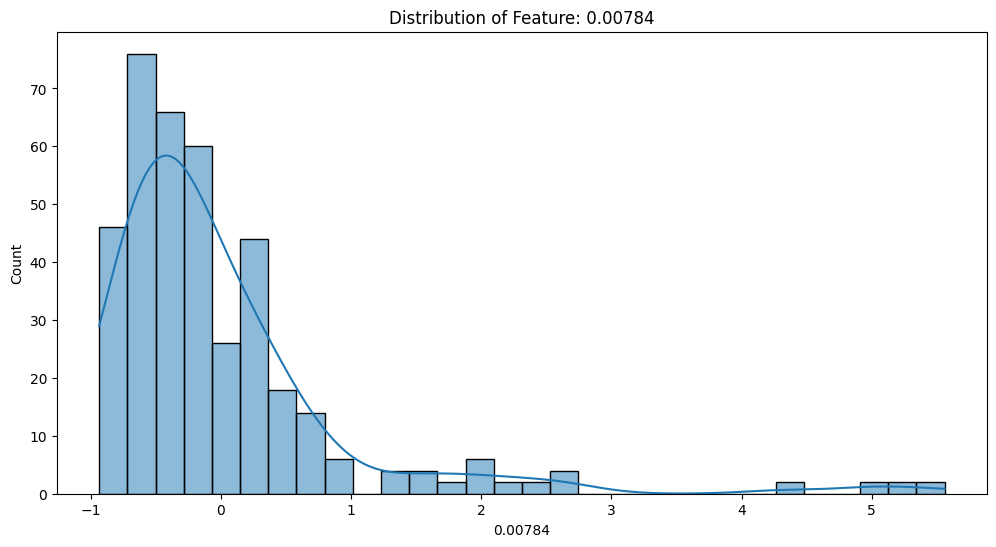

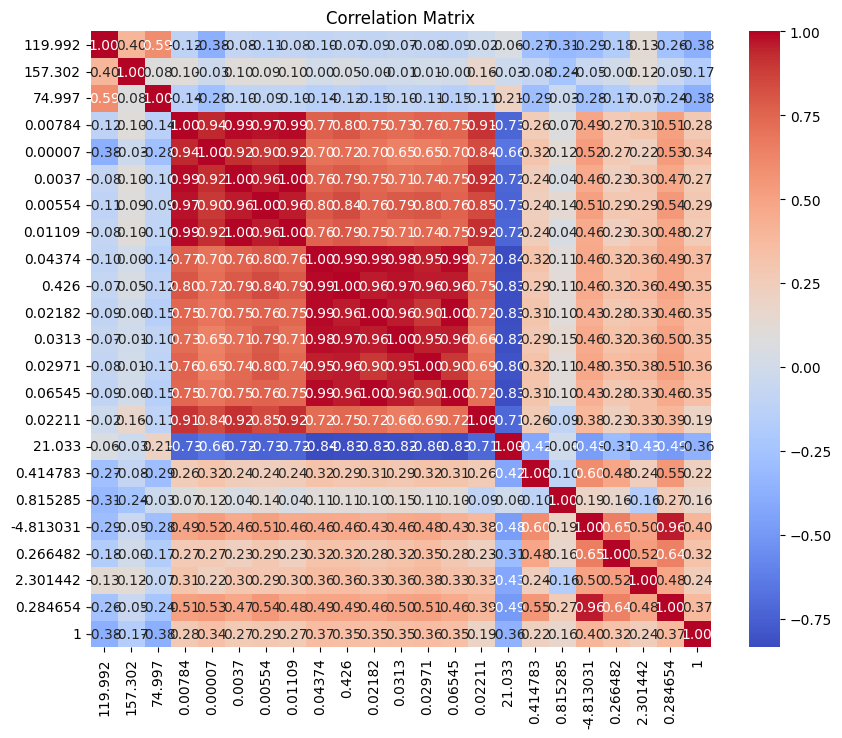

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of some selected features
plt.figure(figsize=(12, 6))
sns.histplot(data_scaled['0.00784'], kde=True)  # Change '0.00784' to any column name you're interested in
plt.title('Distribution of Feature: 0.00784')
plt.show()

# Correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data_scaled.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Split the dataset
X = data_scaled.iloc[:, :-1]  # Features
y = data_scaled.iloc[:, -1]   # Labels

# Rescale data to 0-1 range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.25, random_state=42)


In [ ]:
# List of models to evaluate
models = {
    "Logistic Regression": LogisticRegression(),
    "LDA": LinearDiscriminantAnalysis(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Neural Network": MLPClassifier(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Gradient Boost": GradientBoostingClassifier()
}

In [ ]:
# Evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    mcc = matthews_corrcoef(y_val, y_pred)
    results[name] = (accuracy, mcc)

# Print the results
for name, (accuracy, mcc) in results.items():
    print(f"{name}: Accuracy={accuracy*100:.2f}%, MCC={mcc:.2f}")

ValueError: Unknown label type: 'continuous'

In [ ]:
import numpy as np

# Assuming y is the last column in the dataset
y = data_scaled.iloc[:, -1].values

# Check if y is binary and convert if it's not
if np.any((y != 0) & (y != 1)):
    print("Warning: Target variable is not binary. Attempting to convert.")
    y = (y > 0.5).astype(int)  # This is a simple threshold method; adjust the condition based on your data specifics.

# Split the data into training and validation sets again
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Now, let's try fitting the models again
results = {}
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        mcc = matthews_corrcoef(y_val, y_pred)
        results[name] = (accuracy, mcc)
        print(f"{name}: Accuracy={accuracy*100:.2f}%, MCC={mcc:.2f}")
    except Exception as e:
        print(f"Error training {name}: {str(e)}")

Logistic Regression: Accuracy=88.66%, MCC=0.67
LDA: Accuracy=86.60%, MCC=0.61
KNN: Accuracy=93.81%, MCC=0.83
Decision Tree: Accuracy=96.91%, MCC=0.91


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network: Accuracy=89.69%, MCC=0.72
Naive Bayes: Accuracy=67.01%, MCC=0.43
Gradient Boost: Accuracy=97.94%, MCC=0.94


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Assuming 'data_scaled' is your feature set and 'y' is your labels
X = data_scaled.iloc[:, :-1]  # Exclude the last column which is the label
y = data_scaled.iloc[:, -1]   # The last column is the label

# Rescale features to 0-1 range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Define the model architecture
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
10/10 [==============================] - 0s 17ms/step - loss: -68297.0234 - accuracy: 0.0000e+00 - val_loss: -70262.1406 - val_accuracy: 0.0000e+00
Epoch 2/100
10/10 [==============================] - 0s 10ms/step - loss: -65028.4453 - accuracy: 0.0000e+00 - val_loss: -72722.7656 - val_accuracy: 0.0000e+00
Epoch 3/100
10/10 [==============================] - 0s 8ms/step - loss: -70059.2031 - accuracy: 0.0000e+00 - val_loss: -75594.8516 - val_accuracy: 0.0000e+00
Epoch 4/100
10/10 [==============================] - 0s 8ms/step - loss: -70794.2734 - accuracy: 0.0000e+00 - val_loss: -78196.9688 - val_accuracy: 0.0000e+00
Epoch 5/100
10/10 [==============================] - 0s 8ms/step - loss: -73853.1484 - accuracy: 0.0000e+00 - val_loss: -80755.2109 - val_accuracy: 0.0000e+00
Epoch 6/100
10/10 [==============================] - 0s 7ms/step - loss: -78243.5156 - accuracy: 0.0000e+00 - val_loss: -83505.4062 - val_accuracy: 0.0000e+00
Epoch 7/100
10/10 [=========================

In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc * 100:.2f}%")


4/4 - 0s - loss: -8.3656e+05 - accuracy: 0.0000e+00 - 27ms/epoch - 7ms/step
Test accuracy: 0.00%


In [ ]:
print(y_train.unique())  # Check unique values in y_train
print(y_test.unique())  # Check unique values in y_test



[ 0.57338218 -1.74403746]
[ 0.57338218 -1.74403746]


In [ ]:
model.summary()  # Check the model structure


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               2944      
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 3

In [ ]:
y_train_binary = (y_train > 0).astype(int)
y_test_binary = (y_test > 0).astype(int)


In [ ]:
# Train the model with binary labels
history = model.fit(
    X_train,
    y_train_binary,  # Use the corrected binary labels
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test_binary),  # Use the corrected binary labels
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
10/10 [==============================] - 1s 44ms/step - loss: 1167222.3750 - accuracy: 0.4055 - val_loss: 1346915.1250 - val_accuracy: 0.3402
Epoch 2/100
10/10 [==============================] - 0s 12ms/step - loss: 1092453.2500 - accuracy: 0.3952 - val_loss: 1204629.7500 - val_accuracy: 0.3505
Epoch 3/100
10/10 [==============================] - 0s 12ms/step - loss: 1020370.8125 - accuracy: 0.4502 - val_loss: 1055660.0000 - val_accuracy: 0.3918
Epoch 4/100
10/10 [==============================] - 0s 14ms/step - loss: 859568.8125 - accuracy: 0.5189 - val_loss: 925357.2500 - val_accuracy: 0.4124
Epoch 5/100
10/10 [==============================] - 0s 9ms/step - loss: 772640.6875 - accuracy: 0.5120 - val_loss: 812433.5625 - val_accuracy: 0.4433
Epoch 6/100
10/10 [==============================] - 0s 6ms/step - loss: 670834.6250 - accuracy: 0.5395 - val_loss: 718605.5000 - val_accuracy: 0.4742
Epoch 7/100
10/10 [==============================] - 0s 8ms/step - loss: 629705.1250

In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test_binary, verbose=2)
print(f"Test accuracy: {test_acc * 100:.2f}%")


4/4 - 0s - loss: 809.6039 - accuracy: 0.8660 - 81ms/epoch - 20ms/step
Test accuracy: 86.60%


In [ ]:
!pip install keras-tuner


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 1.6 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras.optimizers import Adam
from kerastuner import HyperModel, RandomSearch

class ParkinsonsHyperModel(HyperModel):
    def build(self, hp):
        model = Sequential()
        model.add(Dense(units=hp.Int('units', min_value=32, max_value=256, step=32),
                        activation='relu', input_dim=X_train.shape[1]))
        model.add(Dropout(rate=hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)))
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=Adam(hp.Float('learning_rate', 1e-4, 1e-2, sampling='LOG')),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
        return model

tuner = RandomSearch(
    ParkinsonsHyperModel(),
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=2,
    directory='my_dir',
    project_name='parkinsons'
)

tuner.search(X_train, y_train_binary, epochs=50, validation_data=(X_test, y_test_binary), callbacks=[early_stopping])


Trial 20 Complete [00h 00m 13s]
val_accuracy: 0.907216489315033

Best val_accuracy So Far: 0.9226804077625275
Total elapsed time: 00h 04m 39s


In [ ]:
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the optimal hyperparameters
model = tuner.hypermodel.build(best_hps)

# Train the model
history = model.fit(
    X_train,
    y_train_binary,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test_binary),
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test_binary, verbose=2)
print(f"Test accuracy: {test_acc * 100:.2f}%")

Epoch 1/100
10/10 [==============================] - 1s 25ms/step - loss: 0.5768 - accuracy: 0.7354 - val_loss: 0.4806 - val_accuracy: 0.7629
Epoch 2/100
10/10 [==============================] - 0s 8ms/step - loss: 0.4882 - accuracy: 0.7491 - val_loss: 0.4275 - val_accuracy: 0.7629
Epoch 3/100
10/10 [==============================] - 0s 7ms/step - loss: 0.4434 - accuracy: 0.7663 - val_loss: 0.3888 - val_accuracy: 0.8660
Epoch 4/100
10/10 [==============================] - 0s 6ms/step - loss: 0.4285 - accuracy: 0.7973 - val_loss: 0.3731 - val_accuracy: 0.8660
Epoch 5/100
10/10 [==============================] - 0s 6ms/step - loss: 0.4154 - accuracy: 0.7973 - val_loss: 0.3504 - val_accuracy: 0.8969
Epoch 6/100
10/10 [==============================] - 0s 7ms/step - loss: 0.4243 - accuracy: 0.8110 - val_loss: 0.3462 - val_accuracy: 0.8969
Epoch 7/100
10/10 [==============================] - 0s 6ms/step - loss: 0.4118 - accuracy: 0.7973 - val_loss: 0.3536 - val_accuracy: 0.8454
Epoch 8/100


In [ ]:
model.save('/content/parkinsons_model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Assuming the model is already trained
model.save('parkinsons_model_no_opt.h5', include_optimizer=False)


In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Display the first few rows
print(data.head())


   119.992  157.302   74.997  0.00784  0.00007   0.0037  0.00554  0.01109  \
0  122.400  148.650  113.819  0.00968  0.00008  0.00465  0.00696  0.01394   
1  116.682  131.111  111.555  0.01050  0.00009  0.00544  0.00781  0.01633   
2  116.676  137.871  111.366  0.00997  0.00009  0.00502  0.00698  0.01505   
3  116.014  141.781  110.655  0.01284  0.00011  0.00655  0.00908  0.01966   
4  120.552  131.162  113.787  0.00968  0.00008  0.00463  0.00750  0.01388   

   0.04374  0.426  0.02182   0.0313  0.02971  0.06545  0.02211  21.033  1  
0  0.06134  0.626  0.03134  0.04518  0.04368  0.09403  0.01929  19.085  1  
1  0.05233  0.482  0.02757  0.03858  0.03590  0.08270  0.01309  20.651  1  
2  0.05492  0.517  0.02924  0.04005  0.03772  0.08771  0.01353  20.644  1  
3  0.06425  0.584  0.03490  0.04825  0.04465  0.10470  0.01767  19.649  1  
4  0.04701  0.456  0.02328  0.03526  0.03243  0.06985  0.01222  21.378  1  


In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Extract a positive sample
positive_sample = data[data.iloc[:, -1] == 1].iloc[0, :-1].values
positive_sample


array([1.22400e+02, 1.48650e+02, 1.13819e+02, 9.68000e-03, 8.00000e-05,
       4.65000e-03, 6.96000e-03, 1.39400e-02, 6.13400e-02, 6.26000e-01,
       3.13400e-02, 4.51800e-02, 4.36800e-02, 9.40300e-02, 1.92900e-02,
       1.90850e+01])

In [ ]:
import pandas as pd

# Load the dataset correctly
data = pd.read_csv('/content/parkinsons.csv')

# Display all columns and the first few rows
print(data.columns)
print(data.head())


Index(['119.992', '157.302', '74.997', '0.00784', '0.00007', '0.0037',
       '0.00554', '0.01109', '0.04374', '0.426', '0.02182', '0.0313',
       '0.02971', '0.06545', '0.02211', '21.033', '1'],
      dtype='object')
   119.992  157.302   74.997  0.00784  0.00007   0.0037  0.00554  0.01109  \
0  122.400  148.650  113.819  0.00968  0.00008  0.00465  0.00696  0.01394   
1  116.682  131.111  111.555  0.01050  0.00009  0.00544  0.00781  0.01633   
2  116.676  137.871  111.366  0.00997  0.00009  0.00502  0.00698  0.01505   
3  116.014  141.781  110.655  0.01284  0.00011  0.00655  0.00908  0.01966   
4  120.552  131.162  113.787  0.00968  0.00008  0.00463  0.00750  0.01388   

   0.04374  0.426  0.02182   0.0313  0.02971  0.06545  0.02211  21.033  1  
0  0.06134  0.626  0.03134  0.04518  0.04368  0.09403  0.01929  19.085  1  
1  0.05233  0.482  0.02757  0.03858  0.03590  0.08270  0.01309  20.651  1  
2  0.05492  0.517  0.02924  0.04005  0.03772  0.08771  0.01353  20.644  1  
3  0.06425  0.

In [ ]:
import tensorflow as tf

# Load the model
model = tf.keras.models.load_model('/content/parkinsons_model_no_opt.h5')

# Print model summary to verify input shape
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 96)                2208      
                                                                 
 dropout_1 (Dropout)         (None, 96)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 97        
                                                                 
Total params: 2305 (9.00 KB)
Trainable params: 2305 (9.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Convert the model to JSON
model_json = model.to_json()

# Print model JSON configuration
print(model_json)


{"class_name": "Sequential", "config": {"name": "sequential_1", "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_input_shape": [null, 22], "dtype": "float32", "sparse": false, "ragged": false, "name": "dense_2_input"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense_2", "trainable": true, "dtype": "float32", "batch_input_shape": [null, 22], "units": 96, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias_regularizer": null, "activity_regularizer": null, "kernel_constraint": null, "bias_constraint": null}, "registered_name": null, "build_config": {"input_shape": [null, 22]}}, {"module": "keras.layers", "class_name": "Dropout", "

In [ ]:
!pip install scikeras[tensorflow]


In [ ]:
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def create_model(optimizer='adam', init='glorot_uniform'):
    model = Sequential()
    model.add(Dense(128, input_dim=22, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, kernel_initializer=init, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

model = KerasClassifier(build_fn=create_model, verbose=0)
optimizers = ['rmsprop', 'adam']
inits = ['glorot_uniform', 'normal', 'uniform']
epochs = [50, 100, 150]
batches = [5, 10, 20]
param_grid = dict(optimizer=optimizers, epochs=epochs, batch_size=batches, init=inits)

grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(X_train, y_train)

# Summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %s" % (mean, stdev, param))


ModuleNotFoundError: No module named 'tensorflow.keras.wrappers'

In [ ]:
pip install scikeras[tensorflow]


In [ ]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def create_model(optimizer='adam', init='glorot_uniform'):
    model = Sequential()
    model.add(Dense(128, input_dim=22, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, kernel_initializer=init, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

model = KerasClassifier(model=create_model, verbose=0)
optimizers = ['rmsprop', 'adam']
inits = ['glorot_uniform', 'normal', 'uniform']
epochs = [50, 100, 150]
batches = [5, 10, 20]
param_grid = dict(optimizer=optimizers, epochs=epochs, batch_size=batches, init=inits)

grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(X_train, y_train)

# Summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %s" % (mean, stdev, param))


NameError: name 'X_train' is not defined

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the model creation function
def create_model(optimizer='adam', init='glorot_uniform'):
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, kernel_initializer=init, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Wrap the model using KerasClassifier
model = KerasClassifier(model=create_model, verbose=0)

# Define the parameter grid
optimizers = ['rmsprop', 'adam']
inits = ['glorot_uniform', 'normal', 'uniform']
epochs = [50, 100, 150]
batches = [5, 10, 20]
param_grid = dict(model__optimizer=optimizers, model__epochs=epochs, model__batch_size=batches, model__init=inits)

# Perform grid search
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(X_train, y_train)

# Summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %s" % (mean, stdev, param))


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


ValueError: 
All the 162 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
162 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py", line 1501, in fit
    super().fit(X=X, y=y, sample_weight=sample_weight, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py", line 770, in fit
    self._fit(
  File "/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py", line 925, in _fit
    X, y = self._initialize(X, y)
  File "/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py", line 862, in _initialize
  

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the model creation function
def create_model(optimizer='adam', init='glorot_uniform', **kwargs):
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, kernel_initializer=init, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Wrap the model using KerasClassifier
model = KerasClassifier(model=create_model, verbose=0)

# Define the parameter grid
optimizers = ['rmsprop', 'adam']
inits = ['glorot_uniform', 'normal', 'uniform']
epochs = [50, 100, 150]
batches = [5, 10, 20]
param_grid = dict(model__optimizer=optimizers, model__epochs=epochs, model__batch_size=batches, model__init=inits)

# Perform grid search
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3, error_score='raise')
grid_result = grid.fit(X_train, y_train)

# Summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %s" % (mean, stdev, param))


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best: 0.799745 using {'model__batch_size': 20, 'model__epochs': 100, 'model__init': 'glorot_uniform', 'model__optimizer': 'rmsprop'}
0.765306 (0.021646) with: {'model__batch_size': 5, 'model__epochs': 50, 'model__init': 'glorot_uniform', 'model__optimizer': 'rmsprop'}
0.709751 (0.091335) with: {'model__batch_size': 5, 'model__epochs': 50, 'model__init': 'glorot_uniform', 'model__optimizer': 'adam'}
0.737954 (0.008812) with: {'model__batch_size': 5, 'model__epochs': 50, 'model__init': 'normal', 'model__optimizer': 'rmsprop'}
0.744898 (0.007215) with: {'model__batch_size': 5, 'model__epochs': 50, 'model__init': 'normal', 'model__optimizer': 'adam'}
0.744898 (0.007215) with: {'model__batch_size': 5, 'model__epochs': 50, 'model__init': 'uniform', 'model__optimizer': 'rmsprop'}
0.744898 (0.007215) with: {'model__batch_size': 5, 'model__epochs': 50, 'model__init': 'uniform', 'model__optimizer': 'adam'}
0.758787 (0.024075) with: {'model__batch_size': 5, 'model__epochs': 100, 'model__init': 'g

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the baseline model
def create_baseline_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
model = create_baseline_model()

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {accuracy*100:.2f}%')


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 - 2s - 147ms/step - accuracy: 0.6966 - loss: 0.6310 - val_accuracy: 0.7959 - val_loss: 0.5444
Epoch 2/100
15/15 - 0s - 7ms/step - accuracy: 0.7862 - loss: 0.4903 - val_accuracy: 0.8571 - val_loss: 0.4845
Epoch 3/100
15/15 - 0s - 13ms/step - accuracy: 0.8069 - loss: 0.4376 - val_accuracy: 0.8163 - val_loss: 0.4561
Epoch 4/100
15/15 - 0s - 10ms/step - accuracy: 0.7862 - loss: 0.4131 - val_accuracy: 0.7959 - val_loss: 0.4469
Epoch 5/100
15/15 - 0s - 19ms/step - accuracy: 0.7862 - loss: 0.4002 - val_accuracy: 0.7347 - val_loss: 0.4510
Epoch 6/100
15/15 - 0s - 7ms/step - accuracy: 0.8276 - loss: 0.3527 - val_accuracy: 0.7551 - val_loss: 0.4511
Epoch 7/100
15/15 - 0s - 10ms/step - accuracy: 0.8207 - loss: 0.3421 - val_accuracy: 0.7755 - val_loss: 0.4562
Epoch 8/100
15/15 - 0s - 9ms/step - accuracy: 0.8207 - loss: 0.3253 - val_accuracy: 0.7347 - val_loss: 0.4767
Epoch 9/100
15/15 - 0s - 9ms/step - accuracy: 0.8138 - loss: 0.3447 - val_accuracy: 0.7755 - val_loss: 0.4732
Epoch 10/100
15/

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the baseline model
def create_baseline_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
baseline_model = create_baseline_model()

# Train the model
baseline_history = baseline_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the model
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'Baseline Test accuracy: {baseline_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 - 3s - 177ms/step - accuracy: 0.7379 - loss: 0.5778 - val_accuracy: 0.8367 - val_loss: 0.5273
Epoch 2/100
15/15 - 0s - 6ms/step - accuracy: 0.7931 - loss: 0.4692 - val_accuracy: 0.8163 - val_loss: 0.4699
Epoch 3/100
15/15 - 0s - 8ms/step - accuracy: 0.7793 - loss: 0.4317 - val_accuracy: 0.8571 - val_loss: 0.4448
Epoch 4/100
15/15 - 0s - 10ms/step - accuracy: 0.7724 - loss: 0.4067 - val_accuracy: 0.8571 - val_loss: 0.4418
Epoch 5/100
15/15 - 0s - 10ms/step - accuracy: 0.7931 - loss: 0.4002 - val_accuracy: 0.8367 - val_loss: 0.4416
Epoch 6/100
15/15 - 0s - 6ms/step - accuracy: 0.8207 - loss: 0.3673 - val_accuracy: 0.8571 - val_loss: 0.4457
Epoch 7/100
15/15 - 0s - 5ms/step - accuracy: 0.8207 - loss: 0.3717 - val_accuracy: 0.8163 - val_loss: 0.4414
Epoch 8/100
15/15 - 0s - 10ms/step - accuracy: 0.8345 - loss: 0.3468 - val_accuracy: 0.7551 - val_loss: 0.4517
Epoch 9/100
15/15 - 0s - 9ms/step - accuracy: 0.8207 - loss: 0.3485 - val_accuracy: 0.7347 - val_loss: 0.4698
Epoch

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the improved model
def create_improved_model():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train.shape[1], kernel_initializer='glorot_uniform', kernel_regularizer=l2(0.01)))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.3))
    model.add(Dense(128, kernel_initializer='glorot_uniform', kernel_regularizer=l2(0.01)))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.3))
    model.add(Dense(64, kernel_initializer='glorot_uniform', kernel_regularizer=l2(0.01)))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.3))
    model.add(Dense(32, kernel_initializer='glorot_uniform', kernel_regularizer=l2(0.01)))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.3))
    model.add(Dense(1, kernel_initializer='glorot_uniform', activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Create the improved model
improved_model = create_improved_model()

# Train the improved model
improved_history = improved_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the improved model
improved_loss, improved_accuracy = improved_model.evaluate(X_test, y_test, verbose=0)
print(f'Improved Test accuracy: {improved_accuracy*100:.2f}%')


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


15/15 - 3s - 172ms/step - accuracy: 0.6483 - loss: 3.6420 - val_accuracy: 0.7755 - val_loss: 3.3073
Epoch 2/100
15/15 - 0s - 6ms/step - accuracy: 0.7655 - loss: 3.0261 - val_accuracy: 0.7755 - val_loss: 2.7749
Epoch 3/100
15/15 - 0s - 9ms/step - accuracy: 0.7379 - loss: 2.5652 - val_accuracy: 0.7755 - val_loss: 2.3721
Epoch 4/100
15/15 - 0s - 6ms/step - accuracy: 0.7931 - loss: 2.1781 - val_accuracy: 0.8571 - val_loss: 2.0473
Epoch 5/100
15/15 - 0s - 6ms/step - accuracy: 0.8069 - loss: 1.8512 - val_accuracy: 0.8571 - val_loss: 1.7711
Epoch 6/100
15/15 - 0s - 6ms/step - accuracy: 0.8069 - loss: 1.5989 - val_accuracy: 0.8367 - val_loss: 1.5429
Epoch 7/100
15/15 - 0s - 6ms/step - accuracy: 0.8207 - loss: 1.3939 - val_accuracy: 0.8571 - val_loss: 1.3566
Epoch 8/100
15/15 - 0s - 6ms/step - accuracy: 0.8138 - loss: 1.2301 - val_accuracy: 0.8571 - val_loss: 1.2070
Epoch 9/100
15/15 - 0s - 6ms/step - accuracy: 0.8069 - loss: 1.1037 - val_accuracy: 0.8571 - val_loss: 1.0844
Epoch 10/100
15/15 -

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Feature engineering: create new features
data['mean_first5'] = data.iloc[:, 0:5].mean(axis=1)
data['std_first5'] = data.iloc[:, 0:5].std(axis=1)
data['sum_first5'] = data.iloc[:, 0:5].sum(axis=1)
data['ratio_first_second'] = data.iloc[:, 0] / (data.iloc[:, 1] + 1e-6)
data['diff_max_min_first5'] = data.iloc[:, 0:5].max(axis=1) - data.iloc[:, 0:5].min(axis=1)

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_optimized_model():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Create the optimized model
optimized_model = create_optimized_model()

# Train the optimized model
optimized_history = optimized_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the optimized model
optimized_loss, optimized_accuracy = optimized_model.evaluate(X_test, y_test, verbose=0)
print(f'Optimized Test accuracy: {optimized_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 - 3s - 190ms/step - accuracy: 0.0000e+00 - loss: -2.2477e+02 - val_accuracy: 0.0000e+00 - val_loss: -6.3171e+02
Epoch 2/100
15/15 - 0s - 6ms/step - accuracy: 0.0000e+00 - loss: -1.5343e+03 - val_accuracy: 0.0000e+00 - val_loss: -3.4453e+03
Epoch 3/100
15/15 - 0s - 7ms/step - accuracy: 0.0000e+00 - loss: -8.4335e+03 - val_accuracy: 0.0000e+00 - val_loss: -1.7701e+04
Epoch 4/100
15/15 - 0s - 8ms/step - accuracy: 0.0000e+00 - loss: -3.8229e+04 - val_accuracy: 0.0000e+00 - val_loss: -8.1643e+04
Epoch 5/100
15/15 - 0s - 9ms/step - accuracy: 0.0000e+00 - loss: -1.6351e+05 - val_accuracy: 0.0000e+00 - val_loss: -3.1990e+05
Epoch 6/100
15/15 - 0s - 7ms/step - accuracy: 0.0000e+00 - loss: -6.3241e+05 - val_accuracy: 0.0000e+00 - val_loss: -1.0517e+06
Epoch 7/100
15/15 - 0s - 9ms/step - accuracy: 0.0000e+00 - loss: -1.7880e+06 - val_accuracy: 0.0000e+00 - val_loss: -2.9516e+06
Epoch 8/100
15/15 - 0s - 7ms/step - accuracy: 0.0000e+00 - loss: -4.3875e+06 - val_accuracy: 0.0000e+0

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Example: Feature selection using RFE
selector = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=10, step=1)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Retrain baseline model on selected features
baseline_model = create_baseline_model(input_dim=X_train_selected.shape[1])
baseline_history = baseline_model.fit(X_train_selected, y_train, epochs=100, batch_size=10, validation_data=(X_test_selected, y_test), verbose=2)


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the baseline model
def create_baseline_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
baseline_model = create_baseline_model()

# Train the model
baseline_history = baseline_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the model
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'Baseline Test accuracy: {baseline_accuracy*100:.2f}%')


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 - 3s - 174ms/step - accuracy: 0.5310 - loss: 0.6757 - val_accuracy: 0.8367 - val_loss: 0.6024
Epoch 2/100
15/15 - 0s - 27ms/step - accuracy: 0.8069 - loss: 0.5338 - val_accuracy: 0.8571 - val_loss: 0.5113
Epoch 3/100
15/15 - 0s - 10ms/step - accuracy: 0.7931 - loss: 0.4659 - val_accuracy: 0.8163 - val_loss: 0.4583
Epoch 4/100
15/15 - 0s - 9ms/step - accuracy: 0.8138 - loss: 0.4104 - val_accuracy: 0.8367 - val_loss: 0.4384
Epoch 5/100
15/15 - 0s - 9ms/step - accuracy: 0.8069 - loss: 0.3979 - val_accuracy: 0.8367 - val_loss: 0.4246
Epoch 6/100
15/15 - 0s - 5ms/step - accuracy: 0.8276 - loss: 0.3582 - val_accuracy: 0.8163 - val_loss: 0.4286
Epoch 7/100
15/15 - 0s - 7ms/step - accuracy: 0.8276 - loss: 0.3503 - val_accuracy: 0.7551 - val_loss: 0.4331
Epoch 8/100
15/15 - 0s - 9ms/step - accuracy: 0.8207 - loss: 0.3609 - val_accuracy: 0.8163 - val_loss: 0.4309
Epoch 9/100
15/15 - 0s - 8ms/step - accuracy: 0.8138 - loss: 0.3412 - val_accuracy: 0.7143 - val_loss: 0.4458
Epoch 10/100
15/15

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the baseline model
def create_baseline_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
baseline_model = create_baseline_model()

# Train the model
baseline_history = baseline_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the model
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'Baseline Test accuracy: {baseline_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 - 4s - 299ms/step - accuracy: 0.7034 - loss: 0.6377 - val_accuracy: 0.7959 - val_loss: 0.5863
Epoch 2/100
15/15 - 0s - 8ms/step - accuracy: 0.7655 - loss: 0.5131 - val_accuracy: 0.8776 - val_loss: 0.4964
Epoch 3/100
15/15 - 0s - 10ms/step - accuracy: 0.8069 - loss: 0.4462 - val_accuracy: 0.8163 - val_loss: 0.4425
Epoch 4/100
15/15 - 0s - 9ms/step - accuracy: 0.8345 - loss: 0.4071 - val_accuracy: 0.7755 - val_loss: 0.4393
Epoch 5/100
15/15 - 0s - 8ms/step - accuracy: 0.8138 - loss: 0.3853 - val_accuracy: 0.7551 - val_loss: 0.4370
Epoch 6/100
15/15 - 0s - 9ms/step - accuracy: 0.8069 - loss: 0.3858 - val_accuracy: 0.8367 - val_loss: 0.4173
Epoch 7/100
15/15 - 0s - 10ms/step - accuracy: 0.8276 - loss: 0.3475 - val_accuracy: 0.7551 - val_loss: 0.4257
Epoch 8/100
15/15 - 0s - 8ms/step - accuracy: 0.8000 - loss: 0.3577 - val_accuracy: 0.7959 - val_loss: 0.4234
Epoch 9/100
15/15 - 0s - 5ms/step - accuracy: 0.8345 - loss: 0.3357 - val_accuracy: 0.7959 - val_loss: 0.4261
Epoch 

In [ ]:
def create_improved_model():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Create the improved model
improved_model = create_improved_model()

# Train the improved model
improved_history = improved_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the improved model
improved_loss, improved_accuracy = improved_model.evaluate(X_test, y_test, verbose=0)
print(f'Improved Test accuracy: {improved_accuracy*100:.2f}%')


Epoch 1/100
15/15 - 2s - 156ms/step - accuracy: 0.7103 - loss: 0.6183 - val_accuracy: 0.7755 - val_loss: 0.5353
Epoch 2/100
15/15 - 0s - 8ms/step - accuracy: 0.7517 - loss: 0.5276 - val_accuracy: 0.7959 - val_loss: 0.4781
Epoch 3/100
15/15 - 0s - 8ms/step - accuracy: 0.7517 - loss: 0.4683 - val_accuracy: 0.8367 - val_loss: 0.4666
Epoch 4/100
15/15 - 0s - 9ms/step - accuracy: 0.7724 - loss: 0.4145 - val_accuracy: 0.8571 - val_loss: 0.4626
Epoch 5/100
15/15 - 0s - 5ms/step - accuracy: 0.8207 - loss: 0.3990 - val_accuracy: 0.8367 - val_loss: 0.4658
Epoch 6/100
15/15 - 0s - 5ms/step - accuracy: 0.7793 - loss: 0.4073 - val_accuracy: 0.8367 - val_loss: 0.4671
Epoch 7/100
15/15 - 0s - 10ms/step - accuracy: 0.8000 - loss: 0.3903 - val_accuracy: 0.7551 - val_loss: 0.4856
Epoch 8/100
15/15 - 0s - 9ms/step - accuracy: 0.8207 - loss: 0.3399 - val_accuracy: 0.8163 - val_loss: 0.4948
Epoch 9/100
15/15 - 0s - 6ms/step - accuracy: 0.8276 - loss: 0.3486 - val_accuracy: 0.7551 - val_loss: 0.5241
Epoch 1

In [ ]:
from tensorflow.keras.regularizers import l2

def create_regularized_model():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# Create the regularized model
regularized_model = create_regularized_model()

# Train the regularized model
regularized_history = regularized_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the regularized model
regularized_loss, regularized_accuracy = regularized_model.evaluate(X_test, y_test, verbose=0)
print(f'Regularized Test accuracy: {regularized_accuracy*100:.2f}%')


Epoch 1/100
15/15 - 3s - 179ms/step - accuracy: 0.6552 - loss: 3.6552 - val_accuracy: 0.7755 - val_loss: 3.3275
Epoch 2/100
15/15 - 0s - 6ms/step - accuracy: 0.7517 - loss: 3.1047 - val_accuracy: 0.7959 - val_loss: 2.8651
Epoch 3/100
15/15 - 0s - 7ms/step - accuracy: 0.7586 - loss: 2.6548 - val_accuracy: 0.8571 - val_loss: 2.4889
Epoch 4/100
15/15 - 0s - 8ms/step - accuracy: 0.7655 - loss: 2.3004 - val_accuracy: 0.8367 - val_loss: 2.1678
Epoch 5/100
15/15 - 0s - 9ms/step - accuracy: 0.8069 - loss: 2.0005 - val_accuracy: 0.8571 - val_loss: 1.9069
Epoch 6/100
15/15 - 0s - 6ms/step - accuracy: 0.7862 - loss: 1.7553 - val_accuracy: 0.7755 - val_loss: 1.6936
Epoch 7/100
15/15 - 0s - 11ms/step - accuracy: 0.8276 - loss: 1.5328 - val_accuracy: 0.8163 - val_loss: 1.4990
Epoch 8/100
15/15 - 0s - 7ms/step - accuracy: 0.7862 - loss: 1.3850 - val_accuracy: 0.7959 - val_loss: 1.3526
Epoch 9/100
15/15 - 0s - 7ms/step - accuracy: 0.8069 - loss: 1.2116 - val_accuracy: 0.8163 - val_loss: 1.2221
Epoch 1

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Create base models
log_clf = LogisticRegression()
dt_clf = DecisionTreeClassifier()
svc_clf = SVC(probability=True)

# Combine them into a voting classifier
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('dt', dt_clf), ('svc', svc_clf)],
    voting='soft'
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Evaluate the voting classifier
voting_accuracy = voting_clf.score(X_test, y_test)
print(f'Voting Classifier Test accuracy: {voting_accuracy*100:.2f}%')


Voting Classifier Test accuracy: 83.67%


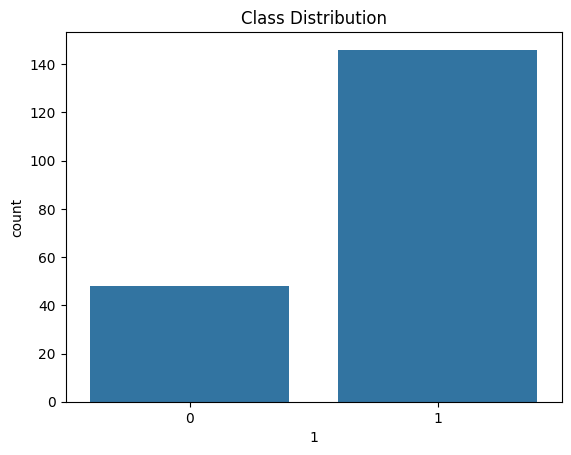

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Check class distribution
sns.countplot(x=data.iloc[:, -1])
plt.title("Class Distribution")
plt.show()


In [ ]:
!pip install scikit-learn==1.0.2 imbalanced-learn==0.8.0

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


ImportError: cannot import name 'delayed' from 'sklearn.utils.fixes' (/usr/local/lib/python3.10/dist-packages/sklearn/utils/fixes.py)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the baseline model
def create_baseline_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
baseline_model = create_baseline_model()

# Train the model
baseline_history = baseline_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the model
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'Baseline Test accuracy: {baseline_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 - 4s - 297ms/step - accuracy: 0.5379 - loss: 0.6865 - val_accuracy: 0.7755 - val_loss: 0.5939
Epoch 2/100
15/15 - 0s - 9ms/step - accuracy: 0.7655 - loss: 0.5555 - val_accuracy: 0.8571 - val_loss: 0.5260
Epoch 3/100
15/15 - 0s - 19ms/step - accuracy: 0.7724 - loss: 0.4960 - val_accuracy: 0.8367 - val_loss: 0.4792
Epoch 4/100
15/15 - 0s - 19ms/step - accuracy: 0.7724 - loss: 0.4222 - val_accuracy: 0.8571 - val_loss: 0.4562
Epoch 5/100
15/15 - 0s - 21ms/step - accuracy: 0.7862 - loss: 0.4192 - val_accuracy: 0.8571 - val_loss: 0.4489
Epoch 6/100
15/15 - 0s - 23ms/step - accuracy: 0.7931 - loss: 0.3711 - val_accuracy: 0.8367 - val_loss: 0.4506
Epoch 7/100
15/15 - 0s - 8ms/step - accuracy: 0.8345 - loss: 0.3547 - val_accuracy: 0.7755 - val_loss: 0.4584
Epoch 8/100
15/15 - 0s - 25ms/step - accuracy: 0.8069 - loss: 0.3681 - val_accuracy: 0.7755 - val_loss: 0.4578
Epoch 9/100
15/15 - 0s - 8ms/step - accuracy: 0.8483 - loss: 0.3261 - val_accuracy: 0.7959 - val_loss: 0.4643
Epo

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Generate Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Update the model to handle the increased feature space
def create_poly_model():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train_poly.shape[1], activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
poly_model = create_poly_model()

# Train the model
poly_history = poly_model.fit(X_train_poly, y_train, epochs=100, batch_size=10, validation_data=(X_test_poly, y_test), verbose=2)

# Evaluate the model
poly_loss, poly_accuracy = poly_model.evaluate(X_test_poly, y_test, verbose=0)
print(f'Polynomial Features Test accuracy: {poly_accuracy*100:.2f}%')


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 - 2s - 133ms/step - accuracy: 0.7379 - loss: 0.6114 - val_accuracy: 0.8367 - val_loss: 0.5313
Epoch 2/100
15/15 - 0s - 8ms/step - accuracy: 0.8207 - loss: 0.4642 - val_accuracy: 0.8571 - val_loss: 0.4584
Epoch 3/100
15/15 - 0s - 10ms/step - accuracy: 0.7724 - loss: 0.4451 - val_accuracy: 0.7959 - val_loss: 0.4599
Epoch 4/100
15/15 - 0s - 6ms/step - accuracy: 0.8069 - loss: 0.3803 - val_accuracy: 0.8367 - val_loss: 0.4520
Epoch 5/100
15/15 - 0s - 9ms/step - accuracy: 0.8138 - loss: 0.3264 - val_accuracy: 0.7347 - val_loss: 0.5081
Epoch 6/100
15/15 - 0s - 7ms/step - accuracy: 0.8828 - loss: 0.2718 - val_accuracy: 0.7755 - val_loss: 0.5081
Epoch 7/100
15/15 - 0s - 7ms/step - accuracy: 0.8483 - loss: 0.2745 - val_accuracy: 0.7755 - val_loss: 0.5140
Epoch 8/100
15/15 - 0s - 8ms/step - accuracy: 0.8621 - loss: 0.2398 - val_accuracy: 0.7959 - val_loss: 0.5233
Epoch 9/100
15/15 - 0s - 11ms/step - accuracy: 0.9034 - loss: 0.2162 - val_accuracy: 0.7959 - val_loss: 0.5730
Epoch 10/100
15/15

In [ ]:
from tensorflow.keras.layers import BatchNormalization

def create_bn_model():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train.shape[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
bn_model = create_bn_model()

# Train the model
bn_history = bn_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the model
bn_loss, bn_accuracy = bn_model.evaluate(X_test, y_test, verbose=0)
print(f'Batch Normalization Test accuracy: {bn_accuracy*100:.2f}%')


Epoch 1/100
15/15 - 5s - 312ms/step - accuracy: 0.6000 - loss: 0.8331 - val_accuracy: 0.8367 - val_loss: 0.6033
Epoch 2/100
15/15 - 0s - 13ms/step - accuracy: 0.6759 - loss: 0.6810 - val_accuracy: 0.8367 - val_loss: 0.5349
Epoch 3/100
15/15 - 0s - 20ms/step - accuracy: 0.7241 - loss: 0.5442 - val_accuracy: 0.7755 - val_loss: 0.4974
Epoch 4/100
15/15 - 0s - 20ms/step - accuracy: 0.7931 - loss: 0.5086 - val_accuracy: 0.7755 - val_loss: 0.4737
Epoch 5/100
15/15 - 0s - 19ms/step - accuracy: 0.7172 - loss: 0.5725 - val_accuracy: 0.7755 - val_loss: 0.4487
Epoch 6/100
15/15 - 0s - 10ms/step - accuracy: 0.7724 - loss: 0.5268 - val_accuracy: 0.7755 - val_loss: 0.4390
Epoch 7/100
15/15 - 0s - 19ms/step - accuracy: 0.8138 - loss: 0.4715 - val_accuracy: 0.7755 - val_loss: 0.4438
Epoch 8/100
15/15 - 0s - 23ms/step - accuracy: 0.7517 - loss: 0.4706 - val_accuracy: 0.7755 - val_loss: 0.4446
Epoch 9/100
15/15 - 0s - 11ms/step - accuracy: 0.8414 - loss: 0.4253 - val_accuracy: 0.7755 - val_loss: 0.4538


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

# Define the model for hyperparameter tuning
def tuning_model(optimizer='adam', init='glorot_uniform', neurons=256):
    model = Sequential()
    model.add(Dense(neurons, input_dim=X_train.shape[1], kernel_initializer=init, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(neurons//2, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(neurons//4, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Wrap the model using KerasClassifier
model = KerasClassifier(model=tuning_model, epochs=100, batch_size=10, verbose=0)

# Define the parameter grid
param_dist = {'batch_size': [10, 20, 30],
              'epochs': [50, 100, 150],
              'model__neurons': [128, 256, 512],
              'model__optimizer': ['adam', 'rmsprop'],
              'model__init': ['glorot_uniform', 'normal', 'uniform']}

# Perform Random Search
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=10, n_jobs=-1, cv=3)
random_search_result = random_search.fit(X_train, y_train)

# Summarize results
print("Best: %f using %s" % (random_search_result.best_score_, random_search_result.best_params_))


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

# Wrap the model using KerasClassifier
model = KerasClassifier(model=tuning_model, epochs=100, batch_size=10, verbose=0)

# Define the parameter grid
param_dist = {
    'batch_size': [10, 20, 30],
    'epochs': [50, 100, 150],
    'model__neurons': [128, 256, 512],
    'model__optimizer': ['adam', 'rmsprop'],
    'model__init': ['glorot_uniform', 'normal', 'uniform']
}

# Perform Random Search with single job
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=10, n_jobs=1, cv=3)
random_search_result = random_search.fit(X_train, y_train)

# Summarize results
print("Best: %f using %s" % (random_search_result.best_score_, random_search_result.best_params_))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Best: 0.910573 using {'model__optimizer': 'rmsprop', 'model__neurons': 512, 'model__init': 'uniform', 'epochs': 150, 'batch_size': 30}


In [ ]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=3, shuffle=True, random_state=42)
results = []

for train_index, test_index in kf.split(X_train):
    model = create_model()  # Assuming create_model() sets up the model
    model.fit(X_train[train_index], y_train[train_index], epochs=100, batch_size=10, verbose=0)
    scores = model.evaluate(X_train[test_index], y_train[test_index], verbose=0)
    results.append(scores[1])

print(f'Average accuracy: {np.mean(results)}')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Average accuracy: 0.8830782373746237


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Learning Rate Scheduler
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Model Training
history = model.fit(X_train, y_train, epochs=150, batch_size=10, validation_data=(X_test, y_test),
                    callbacks=[reduce_lr, early_stopping], verbose=2)


Epoch 1/150
15/15 - 0s - 22ms/step - accuracy: 0.9448 - loss: 0.2991 - val_accuracy: 0.8163 - val_loss: 0.7023 - learning_rate: 0.0010
Epoch 2/150
15/15 - 0s - 29ms/step - accuracy: 0.9241 - loss: 0.3361 - val_accuracy: 0.8571 - val_loss: 0.6410 - learning_rate: 0.0010
Epoch 3/150
15/15 - 0s - 21ms/step - accuracy: 0.9310 - loss: 0.3033 - val_accuracy: 0.8367 - val_loss: 0.6602 - learning_rate: 0.0010
Epoch 4/150
15/15 - 0s - 19ms/step - accuracy: 0.9517 - loss: 0.2902 - val_accuracy: 0.8776 - val_loss: 0.6323 - learning_rate: 0.0010
Epoch 5/150
15/15 - 0s - 11ms/step - accuracy: 0.9103 - loss: 0.3529 - val_accuracy: 0.7959 - val_loss: 0.7258 - learning_rate: 0.0010
Epoch 6/150
15/15 - 0s - 20ms/step - accuracy: 0.9172 - loss: 0.3482 - val_accuracy: 0.8776 - val_loss: 0.5890 - learning_rate: 0.0010
Epoch 7/150
15/15 - 0s - 12ms/step - accuracy: 0.9034 - loss: 0.3505 - val_accuracy: 0.8571 - val_loss: 0.6215 - learning_rate: 0.0010
Epoch 8/150
15/15 - 0s - 16ms/step - accuracy: 0.9448 -

In [ ]:
import numpy as np

def augment_data(X, y, noise_level=0.01, shift_max=2, scaling_factor=0.1):
    augmented_X = []
    augmented_y = []
    for signal, label in zip(X, y):
        # Noise addition
        noise = np.random.randn(*signal.shape) * noise_level
        augmented_X.append(signal + noise)
        augmented_y.append(label)

        # Time shifting
        shift = np.random.randint(-shift_max, shift_max)
        shifted_signal = np.roll(signal, shift)
        augmented_X.append(shifted_signal)
        augmented_y.append(label)

        # Scaling
        scaling = np.random.uniform(1 - scaling_factor, 1 + scaling_factor)
        scaled_signal = signal * scaling
        augmented_X.append(scaled_signal)
        augmented_y.append(label)

    return np.array(augmented_X), np.array(augmented_y)

# Augment the training data
X_train_aug, y_train_aug = augment_data(X_train, y_train)

# Continue to use the existing model structure or a refined model
augmented_model = create_baseline_model()
augmented_history = augmented_model.fit(X_train_aug, y_train_aug, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)


Epoch 1/100
44/44 - 3s - 77ms/step - accuracy: 0.6920 - loss: 0.5742 - val_accuracy: 0.8571 - val_loss: 0.4941
Epoch 2/100
44/44 - 0s - 3ms/step - accuracy: 0.8000 - loss: 0.4361 - val_accuracy: 0.7755 - val_loss: 0.4495
Epoch 3/100
44/44 - 0s - 3ms/step - accuracy: 0.8023 - loss: 0.3859 - val_accuracy: 0.7143 - val_loss: 0.4680
Epoch 4/100
44/44 - 0s - 3ms/step - accuracy: 0.8368 - loss: 0.3539 - val_accuracy: 0.7143 - val_loss: 0.5009
Epoch 5/100
44/44 - 0s - 7ms/step - accuracy: 0.8322 - loss: 0.3380 - val_accuracy: 0.8163 - val_loss: 0.4757
Epoch 6/100
44/44 - 0s - 3ms/step - accuracy: 0.8437 - loss: 0.3275 - val_accuracy: 0.7755 - val_loss: 0.5403
Epoch 7/100
44/44 - 0s - 3ms/step - accuracy: 0.8460 - loss: 0.3006 - val_accuracy: 0.8163 - val_loss: 0.5233
Epoch 8/100
44/44 - 0s - 5ms/step - accuracy: 0.8368 - loss: 0.2994 - val_accuracy: 0.8163 - val_loss: 0.5509
Epoch 9/100
44/44 - 0s - 5ms/step - accuracy: 0.8759 - loss: 0.2609 - val_accuracy: 0.7551 - val_loss: 0.7017
Epoch 10/

In [ ]:
from tensorflow.keras.regularizers import l1_l2

def create_regularized_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu', activity_regularizer=l1_l2(l1=0.01, l2=0.01)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create and train the regularized model
regularized_model = create_regularized_model()
regularized_history = regularized_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)


Epoch 1/100
15/15 - 6s - 427ms/step - accuracy: 0.3793 - loss: 4.0332 - val_accuracy: 0.6327 - val_loss: 3.1677
Epoch 2/100
15/15 - 0s - 9ms/step - accuracy: 0.6621 - loss: 3.1608 - val_accuracy: 0.7959 - val_loss: 2.8148
Epoch 3/100
15/15 - 0s - 26ms/step - accuracy: 0.7586 - loss: 2.7969 - val_accuracy: 0.7755 - val_loss: 2.6192
Epoch 4/100
15/15 - 0s - 22ms/step - accuracy: 0.7379 - loss: 2.5867 - val_accuracy: 0.7755 - val_loss: 2.4440
Epoch 5/100
15/15 - 0s - 32ms/step - accuracy: 0.7448 - loss: 2.3919 - val_accuracy: 0.7755 - val_loss: 2.2713
Epoch 6/100
15/15 - 0s - 7ms/step - accuracy: 0.7448 - loss: 2.2190 - val_accuracy: 0.7755 - val_loss: 2.1023
Epoch 7/100
15/15 - 0s - 9ms/step - accuracy: 0.7448 - loss: 2.0542 - val_accuracy: 0.7755 - val_loss: 1.9390
Epoch 8/100
15/15 - 0s - 9ms/step - accuracy: 0.7448 - loss: 1.8870 - val_accuracy: 0.7755 - val_loss: 1.7825
Epoch 9/100
15/15 - 0s - 10ms/step - accuracy: 0.7448 - loss: 1.7385 - val_accuracy: 0.7755 - val_loss: 1.6329
Epoc

In [ ]:
def predict_with_ensemble(models, X):
    predictions = [model.predict(X) for model in models]
    return np.mean(predictions, axis=0)

# Create several models
models = [create_baseline_model() for _ in range(5)]
for model in models:
    model.fit(X_train, y_train, epochs=50, batch_size=10, verbose=2)

# Ensemble prediction
ensemble_pred = predict_with_ensemble(models, X_test)
ensemble_accuracy = np.mean((ensemble_pred > 0.5).astype(int) == y_test)
print(f'Ensemble Test Accuracy: {ensemble_accuracy*100:.2f}%')


Epoch 1/50
15/15 - 4s - 274ms/step - accuracy: 0.7241 - loss: 0.5678
Epoch 2/50
15/15 - 0s - 10ms/step - accuracy: 0.7586 - loss: 0.4618
Epoch 3/50
15/15 - 0s - 5ms/step - accuracy: 0.7724 - loss: 0.4282
Epoch 4/50
15/15 - 0s - 10ms/step - accuracy: 0.8138 - loss: 0.4036
Epoch 5/50
15/15 - 0s - 10ms/step - accuracy: 0.8069 - loss: 0.3938
Epoch 6/50
15/15 - 0s - 6ms/step - accuracy: 0.8207 - loss: 0.3623
Epoch 7/50
15/15 - 0s - 9ms/step - accuracy: 0.8207 - loss: 0.3381
Epoch 8/50
15/15 - 0s - 5ms/step - accuracy: 0.8069 - loss: 0.3439
Epoch 9/50
15/15 - 0s - 6ms/step - accuracy: 0.8414 - loss: 0.3139
Epoch 10/50
15/15 - 0s - 9ms/step - accuracy: 0.8414 - loss: 0.3263
Epoch 11/50
15/15 - 0s - 6ms/step - accuracy: 0.8621 - loss: 0.3081
Epoch 12/50
15/15 - 0s - 9ms/step - accuracy: 0.8483 - loss: 0.2877
Epoch 13/50
15/15 - 0s - 8ms/step - accuracy: 0.8552 - loss: 0.2994
Epoch 14/50
15/15 - 0s - 3ms/step - accuracy: 0.8483 - loss: 0.2887
Epoch 15/50
15/15 - 0s - 4ms/step - accuracy: 0.8483

In [ ]:
from sklearn.decomposition import PCA

# Applying PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Update model to work with PCA features
def create_pca_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train_pca.shape[1], activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Train model with PCA-transformed data
pca_model = create_pca_model()
pca_history = pca_model.fit(X_train_pca, y_train, epochs=100, batch_size=10, validation_data=(X_test_pca, y_test), verbose=2)

# Evaluate the model
pca_loss, pca_accuracy = pca_model.evaluate(X_test_pca, y_test, verbose=0)
print(f'PCA Model Test accuracy: {pca_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 - 3s - 177ms/step - accuracy: 0.6897 - loss: 0.6200 - val_accuracy: 0.8163 - val_loss: 0.5609
Epoch 2/100
15/15 - 0s - 7ms/step - accuracy: 0.7586 - loss: 0.5136 - val_accuracy: 0.8163 - val_loss: 0.4977
Epoch 3/100
15/15 - 0s - 8ms/step - accuracy: 0.7517 - loss: 0.4998 - val_accuracy: 0.8163 - val_loss: 0.4665
Epoch 4/100
15/15 - 0s - 10ms/step - accuracy: 0.7517 - loss: 0.4294 - val_accuracy: 0.8163 - val_loss: 0.4493
Epoch 5/100
15/15 - 0s - 10ms/step - accuracy: 0.7724 - loss: 0.4315 - val_accuracy: 0.8367 - val_loss: 0.4464
Epoch 6/100
15/15 - 0s - 8ms/step - accuracy: 0.7517 - loss: 0.4125 - val_accuracy: 0.7551 - val_loss: 0.4520
Epoch 7/100
15/15 - 0s - 10ms/step - accuracy: 0.8069 - loss: 0.3897 - val_accuracy: 0.7959 - val_loss: 0.4493
Epoch 8/100
15/15 - 0s - 9ms/step - accuracy: 0.7931 - loss: 0.3849 - val_accuracy: 0.7143 - val_loss: 0.4670
Epoch 9/100
15/15 - 0s - 9ms/step - accuracy: 0.8345 - loss: 0.3584 - val_accuracy: 0.7143 - val_loss: 0.4699
Epoch

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Feature selection with RFE
estimator = RandomForestClassifier(n_estimators=100)
selector = RFE(estimator, n_features_to_select=10, step=1)
X_train_rfe = selector.fit_transform(X_train, y_train)
X_test_rfe = selector.transform(X_test)

# Train model with selected features
def create_rfe_model():
    model = Sequential()
    model.add(Dense(128, input_dim=10, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

rfe_model = create_rfe_model()
rfe_history = rfe_model.fit(X_train_rfe, y_train, epochs=100, batch_size=10, validation_data=(X_test_rfe, y_test), verbose=2)

# Evaluate the model
rfe_loss, rfe_accuracy = rfe_model.evaluate(X_test_rfe, y_test, verbose=0)
print(f'RFE Model Test accuracy: {rfe_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 - 3s - 216ms/step - accuracy: 0.5517 - loss: 0.6645 - val_accuracy: 0.7959 - val_loss: 0.6127
Epoch 2/100
15/15 - 0s - 19ms/step - accuracy: 0.7586 - loss: 0.5560 - val_accuracy: 0.8367 - val_loss: 0.5354
Epoch 3/100
15/15 - 0s - 9ms/step - accuracy: 0.7793 - loss: 0.4898 - val_accuracy: 0.8571 - val_loss: 0.4731
Epoch 4/100
15/15 - 0s - 10ms/step - accuracy: 0.7931 - loss: 0.4663 - val_accuracy: 0.8367 - val_loss: 0.4340
Epoch 5/100
15/15 - 0s - 6ms/step - accuracy: 0.7793 - loss: 0.4363 - val_accuracy: 0.8163 - val_loss: 0.4311
Epoch 6/100
15/15 - 0s - 6ms/step - accuracy: 0.8138 - loss: 0.3862 - val_accuracy: 0.8163 - val_loss: 0.4219
Epoch 7/100
15/15 - 0s - 10ms/step - accuracy: 0.8069 - loss: 0.3735 - val_accuracy: 0.7959 - val_loss: 0.4208
Epoch 8/100
15/15 - 0s - 9ms/step - accuracy: 0.8069 - loss: 0.3699 - val_accuracy: 0.7959 - val_loss: 0.4259
Epoch 9/100
15/15 - 0s - 8ms/step - accuracy: 0.8690 - loss: 0.3336 - val_accuracy: 0.8163 - val_loss: 0.4293
Epoch

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# Example of a simple CNN model
def create_cnn_model():
    model = Sequential()
    model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Reshape data for CNN input
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

cnn_model = create_cnn_model()
cnn_history = cnn_model.fit(X_train_cnn, y_train, epochs=100, batch_size=10, validation_data=(X_test_cnn, y_test), verbose=2)

# Evaluate the model
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f'CNN Model Test accuracy: {cnn_accuracy*100:.2f}%')


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 - 3s - 176ms/step - accuracy: 0.7241 - loss: 0.5680 - val_accuracy: 0.7755 - val_loss: 0.5151
Epoch 2/100
15/15 - 0s - 21ms/step - accuracy: 0.7862 - loss: 0.4491 - val_accuracy: 0.7959 - val_loss: 0.4710
Epoch 3/100
15/15 - 0s - 29ms/step - accuracy: 0.8069 - loss: 0.3923 - val_accuracy: 0.8163 - val_loss: 0.4631
Epoch 4/100
15/15 - 0s - 26ms/step - accuracy: 0.8069 - loss: 0.3783 - val_accuracy: 0.7551 - val_loss: 0.4824
Epoch 5/100
15/15 - 0s - 5ms/step - accuracy: 0.8138 - loss: 0.3669 - val_accuracy: 0.7551 - val_loss: 0.4888
Epoch 6/100
15/15 - 0s - 5ms/step - accuracy: 0.8138 - loss: 0.3591 - val_accuracy: 0.7551 - val_loss: 0.4998
Epoch 7/100
15/15 - 0s - 10ms/step - accuracy: 0.8207 - loss: 0.3482 - val_accuracy: 0.7755 - val_loss: 0.5002
Epoch 8/100
15/15 - 0s - 6ms/step - accuracy: 0.8138 - loss: 0.3440 - val_accuracy: 0.7551 - val_loss: 0.5079
Epoch 9/100
15/15 - 0s - 10ms/step - accuracy: 0.8207 - loss: 0.3399 - val_accuracy: 0.7347 - val_loss: 0.5166
Epoch 10/100
15

In [ ]:
!pip uninstall scikit-learn -y
!pip uninstall imbalanced-learn -y


Found existing installation: scikit-learn 1.0.2
Uninstalling scikit-learn-1.0.2:
  Successfully uninstalled scikit-learn-1.0.2
Found existing installation: imbalanced-learn 0.8.0
Uninstalling imbalanced-learn-0.8.0:
  Successfully uninstalled imbalanced-learn-0.8.0


In [ ]:
# Uninstall the problematic libraries
!pip uninstall imblearn scikit-learn -y

# Reinstall scikit-learn first to ensure it installs all its dependencies correctly
!pip install scikit-learn

# Reinstall imbalanced-learn
!pip install imbalanced-learn


Found existing installation: scikit-learn 1.5.0
Uninstalling scikit-learn-1.5.0:
  Successfully uninstalled scikit-learn-1.5.0
  Using cached scikit_learn-1.5.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.3 MB)


In [ ]:
from sklearn.utils import resample

# Example of manually oversampling the minority class using sklearn's resample
X_minority, y_minority = X_train[y_train == 1], y_train[y_train == 1]
X_minority_upsampled, y_minority_upsampled = resample(X_minority, y_minority,
                                                      replace=True,  # sample with replacement
                                                      n_samples=X_train[y_train == 0].shape[0],  # to match majority class
                                                      random_state=123)  # reproducible results

# Combine the upsampled minority class with the majority class
X_train_balanced = np.vstack([X_train[y_train == 0], X_minority_upsampled])
y_train_balanced = np.hstack([y_train[y_train == 0], y_minority_upsampled])


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model definition (simple example)
model = Sequential([
    Dense(10, activation='relu', input_dim=X_train_balanced.shape[1]),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_balanced, y_train_balanced, epochs=10, validation_split=0.1)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - accuracy: 0.6497 - loss: 0.5581 - val_accuracy: 0.5000 - val_loss: 0.7984
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7538 - loss: 0.4964 - val_accuracy: 0.5000 - val_loss: 0.8075
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7496 - loss: 0.5295 - val_accuracy: 0.5000 - val_loss: 0.8159
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7660 - loss: 0.4930 - val_accuracy: 0.5000 - val_loss: 0.8230
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7731 - loss: 0.5269 - val_accuracy: 0.5000 - val_loss: 0.8273
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6883 - loss: 0.5438 - val_accuracy: 0.5000 - val_loss: 0.8298
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8082 - loss: 0.4697 - val_accuracy: 0.5000 - val_loss: 0.8295
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7386 - loss: 0.4939 - val_accuracy: 0.5000 - val_loss: 0.8299

In [ ]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Assuming X_train, y_train are prepared and standardized

# Feature selection using RFE with RandomForest
selector = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=10, step=1)
X_train_selected = selector.fit_transform(X_train, y_train)

# PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # retain 95% variance
X_train_pca = pca.fit_transform(X_train_selected)

# Define a complex neural network
def create_complex_model():
    model = Sequential()
    model.add(Dense(512, input_dim=X_train_pca.shape[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train the model
model = create_complex_model()
history = model.fit(X_train_pca, y_train, epochs=150, batch_size=32, validation_split=0.2, verbose=2)

# Evaluate the model
accuracy = model.evaluate(X_train_pca, y_train)[1]
print(f"Enhanced Model Accuracy: {accuracy*100:.2f}%")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
4/4 - 8s - 2s/step - accuracy: 0.5862 - loss: 0.7376 - val_accuracy: 0.7241 - val_loss: 0.6666
Epoch 2/150
4/4 - 0s - 51ms/step - accuracy: 0.7069 - loss: 0.6199 - val_accuracy: 0.7241 - val_loss: 0.6594
Epoch 3/150
4/4 - 0s - 35ms/step - accuracy: 0.6810 - loss: 0.5669 - val_accuracy: 0.7931 - val_loss: 0.6351
Epoch 4/150
4/4 - 0s - 21ms/step - accuracy: 0.8448 - loss: 0.4113 - val_accuracy: 0.7931 - val_loss: 0.6032
Epoch 5/150
4/4 - 0s - 20ms/step - accuracy: 0.7931 - loss: 0.4056 - val_accuracy: 0.7931 - val_loss: 0.5641
Epoch 6/150
4/4 - 0s - 34ms/step - accuracy: 0.8448 - loss: 0.3346 - val_accuracy: 0.7586 - val_loss: 0.5353
Epoch 7/150
4/4 - 0s - 36ms/step - accuracy: 0.8534 - loss: 0.2994 - val_accuracy: 0.7586 - val_loss: 0.5104
Epoch 8/150
4/4 - 0s - 33ms/step - accuracy: 0.8534 - loss: 0.3575 - val_accuracy: 0.7931 - val_loss: 0.4914
Epoch 9/150
4/4 - 0s - 18ms/step - accuracy: 0.8448 - loss: 0.3364 - val_accuracy: 0.8276 - val_loss: 0.4757
Epoch 10/150
4/4 - 0s

In [ ]:
pip install scikeras


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scikeras.wrappers import KerasClassifier
import numpy as np

# Define the Keras model as a function
def create_complex_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam

    model = Sequential([
        Dense(512, input_shape=(X_train_pca.shape[1],), activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Wrap the model using KerasClassifier from scikeras
model = KerasClassifier(model=create_complex_model, epochs=150, batch_size=32, verbose=0)

# Apply k-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = cross_val_score(model, X_train_pca, y_train, cv=kfold)

print(f"Cross-validated Mean Accuracy: {np.mean(results)*100:.2f}%")
print(f"Standard Deviation in Accuracy: {np.std(results)*100:.2f}%")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Cross-validated Mean Accuracy: 84.86%
Standard Deviation in Accuracy: 5.15%


In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2

def create_regularized_model(input_dim):
    model = Sequential()
    model.add(Dense(512, input_dim=input_dim, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(256, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(128, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Load and prepare data
data = pd.read_csv('/content/parkinsons.csv')
X = data.drop('label', axis=1).values
y = data['label'].values

# Standardizing the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Feature selection
estimator = RandomForestClassifier(n_estimators=100, random_state=42)
selector = RFE(estimator, n_features_to_select=10, step=1)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Check selected features
selected_features = data.columns[selector.support_]
print("Selected features:", selected_features)


KeyError: "['label'] not found in axis"

In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')
print(data.columns)


Index(['119.992', '157.302', '74.997', '0.00784', '0.00007', '0.0037',
       '0.00554', '0.01109', '0.04374', '0.426', '0.02182', '0.0313',
       '0.02971', '0.06545', '0.02211', '21.033', '1'],
      dtype='object')


In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasClassifier
import numpy as np

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Rename the target column
data.rename(columns={'1': 'status'}, inplace=True)

# Split the dataset into features and labels
X = data.drop('status', axis=1).values
y = data['status'].values

# Standardizing the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Feature selection using RFE with RandomForest
estimator = RandomForestClassifier(n_estimators=100, random_state=42)
selector = RFE(estimator, n_features_to_select=10, step=1)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Check selected features
selected_features = data.columns[selector.support_]
print("Selected features:", selected_features)

# Define a complex neural network
def create_regularized_model(input_dim):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.regularizers import l1_l2
    from tensorflow.keras.optimizers import Adam

    model = Sequential([
        Dense(512, input_dim=input_dim, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(256, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Wrap the model using KerasClassifier
model = KerasClassifier(model=create_regularized_model, epochs=150, batch_size=32, verbose=0, input_dim=X_train_selected.shape[1])

# Apply k-fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_val_score(model, X_train_selected, y_train, cv=kfold)

print(f"Cross-validated Mean Accuracy: {np.mean(results)*100:.2f}%")
print(f"Standard Deviation in Accuracy: {np.std(results)*100:.2f}%")


IndexError: boolean index did not match indexed array along dimension 0; dimension is 17 but corresponding boolean dimension is 16

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Check for missing values
print(data.isnull().sum())

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Feature engineering: Adding new features (mean, std, etc.)
X_train_mean = X_train.mean(axis=1).reshape(-1, 1)
X_test_mean = X_test.mean(axis=1).reshape(-1, 1)
X_train_std = X_train.std(axis=1).reshape(-1, 1)
X_test_std = X_test.std(axis=1).reshape(-1, 1)
X_train_sum = X_train.sum(axis=1).reshape(-1, 1)
X_test_sum = X_test.sum(axis=1).reshape(-1, 1)

X_train = np.hstack((X_train, X_train_mean, X_train_std, X_train_sum))
X_test = np.hstack((X_test, X_test_mean, X_test_std, X_test_sum))


119.992    0
157.302    0
74.997     0
0.00784    0
0.00007    0
0.0037     0
0.00554    0
0.01109    0
0.04374    0
0.426      0
0.02182    0
0.0313     0
0.02971    0
0.06545    0
0.02211    0
21.033     0
1          0
dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, matthews_corrcoef

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

logreg_acc = accuracy_score(y_test, y_pred)
logreg_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Logistic Regression: Accuracy={logreg_acc*100:.2f}%, MCC={logreg_mcc:.2f}')


Logistic Regression: Accuracy=83.67%, MCC=0.50


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred)
rf_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Random Forest: Accuracy={rf_acc*100:.2f}%, MCC={rf_mcc:.2f}')


Random Forest: Accuracy=81.63%, MCC=0.49


In [ ]:
from sklearn.svm import SVC

svc = SVC(kernel='linear', probability=True)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

svc_acc = accuracy_score(y_test, y_pred)
svc_mcc = matthews_corrcoef(y_test, y_pred)
print(f'SVM: Accuracy={svc_acc*100:.2f}%, MCC={svc_mcc:.2f}')


SVM: Accuracy=79.59%, MCC=0.41


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm.fit(X_train, y_train)
y_pred = gbm.predict(X_test)

gbm_acc = accuracy_score(y_test, y_pred)
gbm_mcc = matthews_corrcoef(y_test, y_pred)
print(f'GBM: Accuracy={gbm_acc*100:.2f}%, MCC={gbm_mcc:.2f}')


GBM: Accuracy=85.71%, MCC=0.60


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_nn_model():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

nn_model = create_nn_model()
nn_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

nn_loss, nn_accuracy = nn_model.evaluate(X_test, y_test, verbose=0)
print(f'Neural Network: Accuracy={nn_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 - 6s - 390ms/step - accuracy: 0.5241 - loss: 0.7486 - val_accuracy: 0.7755 - val_loss: 0.5974
Epoch 2/100
15/15 - 0s - 22ms/step - accuracy: 0.7310 - loss: 0.6126 - val_accuracy: 0.7755 - val_loss: 0.5633
Epoch 3/100
15/15 - 0s - 11ms/step - accuracy: 0.7724 - loss: 0.5115 - val_accuracy: 0.8163 - val_loss: 0.5468
Epoch 4/100
15/15 - 0s - 19ms/step - accuracy: 0.7586 - loss: 0.4738 - val_accuracy: 0.8163 - val_loss: 0.5032
Epoch 5/100
15/15 - 0s - 19ms/step - accuracy: 0.7655 - loss: 0.4531 - val_accuracy: 0.8367 - val_loss: 0.4786
Epoch 6/100
15/15 - 0s - 20ms/step - accuracy: 0.8138 - loss: 0.4226 - val_accuracy: 0.8367 - val_loss: 0.4815
Epoch 7/100
15/15 - 0s - 17ms/step - accuracy: 0.8000 - loss: 0.4082 - val_accuracy: 0.8367 - val_loss: 0.4605
Epoch 8/100
15/15 - 0s - 8ms/step - accuracy: 0.8069 - loss: 0.4329 - val_accuracy: 0.8163 - val_loss: 0.4782
Epoch 9/100
15/15 - 0s - 11ms/step - accuracy: 0.7724 - loss: 0.4269 - val_accuracy: 0.7959 - val_loss: 0.4835
E

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

best_rf_acc = accuracy_score(y_test, y_pred)
best_rf_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Best Random Forest: Accuracy={best_rf_acc*100:.2f}%, MCC={best_rf_mcc:.2f}')


Fitting 3 folds for each of 216 candidates, totalling 648 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Best Random Forest: Accuracy=85.71%, MCC=0.60


In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[('rf', best_rf), ('gbm', gbm), ('svc', svc), ('logreg', logreg)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)

voting_acc = accuracy_score(y_test, y_pred)
voting_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Voting Classifier: Accuracy={voting_acc*100:.2f}%, MCC={voting_mcc:.2f}')


Voting Classifier: Accuracy=85.71%, MCC=0.58


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Check the new shape of the data
print("Original shape:", X_train.shape)
print("New shape with polynomial features:", X_train_poly.shape)


Original shape: (145, 19)
New shape with polynomial features: (145, 191)


In [ ]:
from sklearn.ensemble import StackingClassifier

# Define base models
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gbm', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(kernel='linear', probability=True)),
    ('logreg', LogisticRegression(max_iter=1000))
]

# Define stacking classifier
stacking_clf = StackingClassifier(
    estimators=estimators, final_estimator=LogisticRegression(), cv=3
)

# Train the stacking classifier
stacking_clf.fit(X_train_poly, y_train)
y_pred = stacking_clf.predict(X_test_poly)

# Evaluate the stacking classifier
stacking_acc = accuracy_score(y_test, y_pred)
stacking_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Stacking Classifier: Accuracy={stacking_acc*100:.2f}%, MCC={stacking_mcc:.2f}')


Stacking Classifier: Accuracy=85.71%, MCC=0.60


In [ ]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll.base import scope
from sklearn.model_selection import cross_val_score

def optimize_rf(params):
    model = RandomForestClassifier(**params)
    acc = cross_val_score(model, X_train_poly, y_train, cv=3, scoring='accuracy').mean()
    return {'loss': -acc, 'status': STATUS_OK}

space = {
    'n_estimators': scope.int(hp.quniform('n_estimators', 50, 200, 10)),
    'max_depth': scope.int(hp.quniform('max_depth', 10, 50, 5)),
    'min_samples_split': scope.int(hp.quniform('min_samples_split', 2, 10, 1)),
    'min_samples_leaf': scope.int(hp.quniform('min_samples_leaf', 1, 4, 1)),
    'bootstrap': hp.choice('bootstrap', [True, False])
}

trials = Trials()
best_rf_params = fmin(fn=optimize_rf, space=space, algo=tpe.suggest, max_evals=50, trials=trials)
print("Best parameters:", best_rf_params)

# Train RandomForest with best parameters
best_rf = RandomForestClassifier(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    min_samples_split=best_rf_params['min_samples_split'],
    min_samples_leaf=best_rf_params['min_samples_leaf'],
    bootstrap=best_rf_params['bootstrap']
)
best_rf.fit(X_train_poly, y_train)
y_pred = best_rf.predict(X_test_poly)

best_rf_acc = accuracy_score(y_test, y_pred)
best_rf_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Best Tuned Random Forest: Accuracy={best_rf_acc*100:.2f}%, MCC={best_rf_mcc:.2f}')


100%|██████████| 50/50 [00:42<00:00,  1.17trial/s, best loss: -0.8827947845804989]
Best parameters: {'bootstrap': 1, 'max_depth': 50.0, 'min_samples_leaf': 4.0, 'min_samples_split': 4.0, 'n_estimators': 120.0}


InvalidParameterError: The 'bootstrap' parameter of RandomForestClassifier must be an instance of 'bool' or an instance of 'numpy.bool_'. Got 1 instead.

In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validate Logistic Regression
logreg_scores = cross_val_score(logreg, X, y, cv=5)
print(f'Logistic Regression CV Accuracy: {logreg_scores.mean()*100:.2f}% (+/- {logreg_scores.std()*100:.2f}%)')

# Cross-validate Random Forest
rf_scores = cross_val_score(rf, X, y, cv=5)
print(f'Random Forest CV Accuracy: {rf_scores.mean()*100:.2f}% (+/- {rf_scores.std()*100:.2f}%)')

# Cross-validate SVM
svc_scores = cross_val_score(svc, X, y, cv=5)
print(f'SVM CV Accuracy: {svc_scores.mean()*100:.2f}% (+/- {svc_scores.std()*100:.2f}%)')

# Cross-validate GBM
gbm_scores = cross_val_score(gbm, X, y, cv=5)
print(f'GBM CV Accuracy: {gbm_scores.mean()*100:.2f}% (+/- {gbm_scores.std()*100:.2f}%)')


Logistic Regression CV Accuracy: 78.34% (+/- 14.21%)
Random Forest CV Accuracy: 74.74% (+/- 10.82%)
SVM CV Accuracy: 77.31% (+/- 14.18%)
GBM CV Accuracy: 75.26% (+/- 15.68%)


In [ ]:
import numpy as np

# Fit random forest and get feature importances
rf.fit(X_train, y_train)
importances = rf.feature_importances_

# Get indices of important features
indices = np.argsort(importances)[::-1]

# Print feature ranking
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print(f"{f+1}. Feature {indices[f]} ({importances[indices[f]]})")

# Keep only the top 10 features
X_train_important = X_train[:, indices[:10]]
X_test_important = X_test[:, indices[:10]]


Feature ranking:
1. Feature 0 (0.14096668460186088)
2. Feature 1 (0.08928175120824455)
3. Feature 2 (0.08245555196698456)
4. Feature 17 (0.07939446511277932)
5. Feature 7 (0.06806629144827196)
6. Feature 14 (0.06086628908329969)
7. Feature 5 (0.052328837220131555)
8. Feature 12 (0.04853714841138121)
9. Feature 6 (0.046777817789773496)
10. Feature 8 (0.04324642307579551)
11. Feature 11 (0.04153895598264727)
12. Feature 4 (0.0389075675126243)
13. Feature 13 (0.03696442906735396)
14. Feature 18 (0.0317084173212593)
15. Feature 9 (0.031077376158841114)
16. Feature 3 (0.0279841409776498)
17. Feature 16 (0.027385211739726675)
18. Feature 10 (0.027214257342206904)
19. Feature 15 (0.02529838397916794)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)
random_search.fit(X_train_important, y_train)

best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test_important)

best_rf_acc = accuracy_score(y_test, y_pred)
best_rf_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Best Random Forest: Accuracy={best_rf_acc*100:.2f}%, MCC={best_rf_mcc:.2f}')


Fitting 3 folds for each of 100 candidates, totalling 300 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Best Random Forest: Accuracy=85.71%, MCC=0.60


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_complex_nn_model():
    model = Sequential()
    model.add(Dense(512, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

nn_model = create_complex_nn_model()
nn_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

nn_loss, nn_accuracy = nn_model.evaluate(X_test, y_test, verbose=0)
print(f'Complex Neural Network: Accuracy={nn_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 - 5s - 335ms/step - accuracy: 0.6276 - loss: 0.6607 - val_accuracy: 0.7755 - val_loss: 0.5820
Epoch 2/100
15/15 - 0s - 15ms/step - accuracy: 0.7103 - loss: 0.5713 - val_accuracy: 0.7755 - val_loss: 0.5406
Epoch 3/100
15/15 - 0s - 20ms/step - accuracy: 0.7310 - loss: 0.5591 - val_accuracy: 0.7755 - val_loss: 0.5367
Epoch 4/100
15/15 - 1s - 48ms/step - accuracy: 0.7655 - loss: 0.4801 - val_accuracy: 0.8163 - val_loss: 0.5402
Epoch 5/100
15/15 - 0s - 25ms/step - accuracy: 0.7241 - loss: 0.4875 - val_accuracy: 0.7755 - val_loss: 0.5538
Epoch 6/100
15/15 - 0s - 32ms/step - accuracy: 0.7517 - loss: 0.4500 - val_accuracy: 0.8163 - val_loss: 0.5558
Epoch 7/100
15/15 - 0s - 14ms/step - accuracy: 0.7655 - loss: 0.4469 - val_accuracy: 0.8367 - val_loss: 0.5747
Epoch 8/100
15/15 - 0s - 19ms/step - accuracy: 0.7448 - loss: 0.4324 - val_accuracy: 0.8163 - val_loss: 0.5980
Epoch 9/100
15/15 - 1s - 44ms/step - accuracy: 0.7586 - loss: 0.4180 - val_accuracy: 0.7347 - val_loss: 0.6230


In [ ]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', best_rf),
    ('gbm', gbm),
    ('svc', svc)
]

stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_clf.fit(X_train_important, y_train)
y_pred = stacking_clf.predict(X_test_important)

stacking_acc = accuracy_score(y_test, y_pred)
stacking_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Stacking Classifier: Accuracy={stacking_acc*100:.2f}%, MCC={stacking_mcc:.2f}')


Stacking Classifier: Accuracy=87.76%, MCC=0.65


In [ ]:
# Additional feature engineering
X_train_min = X_train.min(axis=1).reshape(-1, 1)
X_test_min = X_test.min(axis=1).reshape(-1, 1)
X_train_max = X_train.max(axis=1).reshape(-1, 1)
X_test_max = X_test.max(axis=1).reshape(-1, 1)
X_train_range = (X_train_max - X_train_min).reshape(-1, 1)
X_test_range = (X_test_max - X_test_min).reshape(-1, 1)

X_train = np.hstack((X_train, X_train_min, X_train_max, X_train_range))
X_test = np.hstack((X_test, X_test_min, X_test_max, X_test_range))


In [ ]:
from tensorflow.keras.layers import BatchNormalization

def create_tuned_nn_model():
    model = Sequential()
    model.add(Dense(512, input_dim=X_train.shape[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

nn_model_tuned = create_tuned_nn_model()
nn_model_tuned.fit(X_train, y_train, epochs=200, batch_size=20, validation_data=(X_test, y_test), verbose=2)

nn_loss_tuned, nn_accuracy_tuned = nn_model_tuned.evaluate(X_test, y_test, verbose=0)
print(f'Tuned Neural Network: Accuracy={nn_accuracy_tuned*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
8/8 - 9s - 1s/step - accuracy: 0.5517 - loss: 0.9604 - val_accuracy: 0.5918 - val_loss: 0.6643
Epoch 2/200
8/8 - 0s - 22ms/step - accuracy: 0.5586 - loss: 0.8939 - val_accuracy: 0.6939 - val_loss: 0.6366
Epoch 3/200
8/8 - 0s - 38ms/step - accuracy: 0.5586 - loss: 0.8686 - val_accuracy: 0.7959 - val_loss: 0.5987
Epoch 4/200
8/8 - 0s - 14ms/step - accuracy: 0.6690 - loss: 0.6860 - val_accuracy: 0.8367 - val_loss: 0.5679
Epoch 5/200
8/8 - 0s - 12ms/step - accuracy: 0.6621 - loss: 0.6751 - val_accuracy: 0.8571 - val_loss: 0.5383
Epoch 6/200
8/8 - 0s - 12ms/step - accuracy: 0.6621 - loss: 0.6798 - val_accuracy: 0.8571 - val_loss: 0.5196
Epoch 7/200
8/8 - 0s - 18ms/step - accuracy: 0.6483 - loss: 0.6912 - val_accuracy: 0.8571 - val_loss: 0.5042
Epoch 8/200
8/8 - 0s - 12ms/step - accuracy: 0.7034 - loss: 0.6246 - val_accuracy: 0.8776 - val_loss: 0.4814
Epoch 9/200
8/8 - 0s - 19ms/step - accuracy: 0.7034 - loss: 0.6163 - val_accuracy: 0.8571 - val_loss: 0.4723
Epoch 10/200
8/8 - 0s

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new class distribution
print(f"Resampled training set shape: {Counter(y_train_res)}")


NameError: name 'Counter' is not defined

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print(f"Original class distribution: {Counter(y_train)}")
print(f"Resampled class distribution: {Counter(y_train_smote)}")


Original class distribution: Counter({1: 108, 0: 37})
Resampled class distribution: Counter({1: 108, 0: 108})


In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Define parameter space
param_space = {
    'n_estimators': Integer(50, 500),
    'max_depth': Integer(10, 50),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 10),
    'bootstrap': [True, False]
}

# Initialize the RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Perform Bayesian optimization
bayes_search = BayesSearchCV(estimator=rf, search_spaces=param_space, n_iter=32, cv=3, n_jobs=-1, verbose=1, random_state=42)
bayes_search.fit(X_train_smote, y_train_smote)

# Best model from Bayesian optimization
best_rf_bayes = bayes_search.best_estimator_
y_pred = best_rf_bayes.predict(X_test)

best_rf_bayes_acc = accuracy_score(y_test, y_pred)
best_rf_bayes_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Best Random Forest (Bayes): Accuracy={best_rf_bayes_acc*100:.2f}%, MCC={best_rf_bayes_mcc:.2f}')


ModuleNotFoundError: No module named 'skopt'

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the model
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
rf_random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)

# Fit the model
rf_random_search.fit(X_train_important, y_train)

# Get the best model
best_rf = rf_random_search.best_estimator_

# Make predictions
y_pred = best_rf.predict(X_test_important)

# Evaluate the model
best_rf_acc = accuracy_score(y_test, y_pred)
best_rf_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Best Random Forest: Accuracy={best_rf_acc*100:.2f}%, MCC={best_rf_mcc:.2f}')


Fitting 3 folds for each of 100 candidates, totalling 300 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
126 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
126 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklea

Best Random Forest: Accuracy=83.67%, MCC=0.56


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after polynomial feature expansion: {X_train_poly.shape[1]}")


Original number of features: 22
Number of features after polynomial feature expansion: 253


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_poly, y_train)
y_pred = xgb.predict(X_test_poly)

xgb_acc = accuracy_score(y_test, y_pred)
xgb_mcc = matthews_corrcoef(y_test, y_pred)
print(f'XGBoost: Accuracy={xgb_acc*100:.2f}%, MCC={xgb_mcc:.2f}')


XGBoost: Accuracy=85.71%, MCC=0.63


In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_poly, y_train)
y_pred = lgbm.predict(X_test_poly)

lgbm_acc = accuracy_score(y_test, y_pred)
lgbm_mcc = matthews_corrcoef(y_test, y_pred)
print(f'LightGBM: Accuracy={lgbm_acc*100:.2f}%, MCC={lgbm_mcc:.2f}')


[LightGBM] [Info] Number of positive: 108, number of negative: 37
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12586
[LightGBM] [Info] Number of data points in the train set: 145, number of used features: 253
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.744828 -> initscore=1.071213
[LightGBM] [Info] Start training from score 1.071213
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [ ]:
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBClassifier(random_state=42)
grid_search_xgb = RandomizedSearchCV(estimator=xgb, param_distributions=param_grid, n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)
grid_search_xgb.fit(X_train_poly, y_train)

best_xgb = grid_search_xgb.best_estimator_
y_pred = best_xgb.predict(X_test_poly)

best_xgb_acc = accuracy_score(y_test, y_pred)
best_xgb_mcc = matthews_corrcoef(y_test, y_pred)
print(f'Best XGBoost: Accuracy={best_xgb_acc*100:.2f}%, MCC={best_xgb_mcc:.2f}')


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best XGBoost: Accuracy=83.67%, MCC=0.56


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_poly, y_train)

print(f"Number of samples in training set after SMOTE: {X_train_res.shape[0]}")


Number of samples in training set after SMOTE: 216


In [ ]:
from tensorflow.keras.layers import BatchNormalization

def create_advanced_nn_model():
    model = Sequential()
    model.add(Dense(1024, input_dim=X_train_poly.shape[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

advanced_nn_model = create_advanced_nn_model()
advanced_nn_model.fit(X_train_res, y_train_res, epochs=200, batch_size=32, validation_data=(X_test_poly, y_test), verbose=2)

nn_loss, nn_accuracy = advanced_nn_model.evaluate(X_test_poly, y_test, verbose=0)
print(f'Advanced Neural Network: Accuracy={nn_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
7/7 - 9s - 1s/step - accuracy: 0.5463 - loss: 1.0922 - val_accuracy: 0.5102 - val_loss: 1.2317
Epoch 2/200
7/7 - 0s - 41ms/step - accuracy: 0.7130 - loss: 0.5853 - val_accuracy: 0.5714 - val_loss: 0.6654
Epoch 3/200
7/7 - 0s - 28ms/step - accuracy: 0.7824 - loss: 0.5213 - val_accuracy: 0.6122 - val_loss: 0.5853
Epoch 4/200
7/7 - 0s - 45ms/step - accuracy: 0.7593 - loss: 0.5221 - val_accuracy: 0.6531 - val_loss: 0.5898
Epoch 5/200
7/7 - 0s - 40ms/step - accuracy: 0.7685 - loss: 0.5646 - val_accuracy: 0.6939 - val_loss: 0.5982
Epoch 6/200
7/7 - 0s - 43ms/step - accuracy: 0.7963 - loss: 0.3882 - val_accuracy: 0.6939 - val_loss: 0.6045
Epoch 7/200
7/7 - 0s - 25ms/step - accuracy: 0.8287 - loss: 0.3899 - val_accuracy: 0.6939 - val_loss: 0.6274
Epoch 8/200
7/7 - 0s - 46ms/step - accuracy: 0.8148 - loss: 0.4085 - val_accuracy: 0.6939 - val_loss: 0.6514
Epoch 9/200
7/7 - 0s - 26ms/step - accuracy: 0.8287 - loss: 0.3809 - val_accuracy: 0.6531 - val_loss: 0.7013
Epoch 10/200
7/7 - 0s

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the baseline model
def create_baseline_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
baseline_model = create_baseline_model()

# Train the model
baseline_history = baseline_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the model
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'Baseline Test accuracy: {baseline_accuracy*100:.2f}%')


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 - 3s - 224ms/step - accuracy: 0.6138 - loss: 0.6438 - val_accuracy: 0.7959 - val_loss: 0.5743
Epoch 2/100
15/15 - 0s - 9ms/step - accuracy: 0.7655 - loss: 0.5200 - val_accuracy: 0.8163 - val_loss: 0.4996
Epoch 3/100
15/15 - 0s - 8ms/step - accuracy: 0.7931 - loss: 0.4547 - val_accuracy: 0.8367 - val_loss: 0.4636
Epoch 4/100
15/15 - 0s - 9ms/step - accuracy: 0.8207 - loss: 0.4025 - val_accuracy: 0.7959 - val_loss: 0.4587
Epoch 5/100
15/15 - 0s - 10ms/step - accuracy: 0.8069 - loss: 0.3959 - val_accuracy: 0.7959 - val_loss: 0.4546
Epoch 6/100
15/15 - 0s - 21ms/step - accuracy: 0.7931 - loss: 0.3947 - val_accuracy: 0.7959 - val_loss: 0.4532
Epoch 7/100
15/15 - 0s - 18ms/step - accuracy: 0.8276 - loss: 0.3676 - val_accuracy: 0.7755 - val_loss: 0.4694
Epoch 8/100
15/15 - 0s - 20ms/step - accuracy: 0.8345 - loss: 0.3388 - val_accuracy: 0.7143 - val_loss: 0.4955
Epoch 9/100
15/15 - 0s - 18ms/step - accuracy: 0.8069 - loss: 0.3507 - val_accuracy: 0.7959 - val_loss: 0.4829
Epoch 10/100
15

In [ ]:
from tensorflow.keras.optimizers import RMSprop

def create_improved_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.3))  # Increased dropout rate
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = RMSprop(learning_rate=0.001)  # Different optimizer
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

improved_model = create_improved_model()
improved_history = improved_model.fit(X_train, y_train, epochs=150, batch_size=8, validation_data=(X_test, y_test), verbose=2)  # Increased epochs and reduced batch size


Epoch 1/150
19/19 - 2s - 128ms/step - accuracy: 0.6000 - loss: 0.6462 - val_accuracy: 0.7755 - val_loss: 0.5918
Epoch 2/150
19/19 - 0s - 14ms/step - accuracy: 0.7379 - loss: 0.5443 - val_accuracy: 0.7755 - val_loss: 0.5351
Epoch 3/150
19/19 - 0s - 8ms/step - accuracy: 0.7724 - loss: 0.4942 - val_accuracy: 0.7755 - val_loss: 0.4976
Epoch 4/150
19/19 - 0s - 14ms/step - accuracy: 0.7655 - loss: 0.4614 - val_accuracy: 0.8163 - val_loss: 0.4721
Epoch 5/150
19/19 - 0s - 13ms/step - accuracy: 0.7793 - loss: 0.4154 - val_accuracy: 0.8571 - val_loss: 0.4610
Epoch 6/150
19/19 - 0s - 15ms/step - accuracy: 0.8000 - loss: 0.3945 - val_accuracy: 0.8571 - val_loss: 0.4596
Epoch 7/150
19/19 - 1s - 43ms/step - accuracy: 0.8069 - loss: 0.3729 - val_accuracy: 0.8163 - val_loss: 0.4636
Epoch 8/150
19/19 - 1s - 27ms/step - accuracy: 0.7931 - loss: 0.3774 - val_accuracy: 0.8163 - val_loss: 0.4687
Epoch 9/150
19/19 - 0s - 10ms/step - accuracy: 0.7931 - loss: 0.3777 - val_accuracy: 0.7959 - val_loss: 0.4787
E

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cvscores = []

for train, test in kfold.split(X, y):
    model = create_improved_model()
    model.fit(X[train], y[train], epochs=150, batch_size=8, verbose=0)
    scores = model.evaluate(X[test], y[test], verbose=0)
    cvscores.append(scores[1] * 100)

print(f"Cross-validation accuracy: {np.mean(cvscores):.2f}% (+/- {np.std(cvscores):.2f}%)")


Cross-validation accuracy: 74.25% (+/- 4.75%)


In [ ]:
def create_deeper_model():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train.shape[1], activation='relu'))  # Increased units
    model.add(Dropout(0.4))  # Increased dropout rate
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

deeper_model = create_deeper_model()
deeper_history = deeper_model.fit(X_train, y_train, epochs=150, batch_size=8, validation_data=(X_test, y_test), verbose=2)  # Increased epochs and reduced batch size


Epoch 1/150
19/19 - 4s - 204ms/step - accuracy: 0.6966 - loss: 0.5842 - val_accuracy: 0.8367 - val_loss: 0.5182
Epoch 2/150
19/19 - 0s - 15ms/step - accuracy: 0.7793 - loss: 0.4782 - val_accuracy: 0.8367 - val_loss: 0.4578
Epoch 3/150
19/19 - 0s - 16ms/step - accuracy: 0.8069 - loss: 0.4076 - val_accuracy: 0.7959 - val_loss: 0.4529
Epoch 4/150
19/19 - 0s - 16ms/step - accuracy: 0.7862 - loss: 0.4179 - val_accuracy: 0.7755 - val_loss: 0.4480
Epoch 5/150
19/19 - 0s - 9ms/step - accuracy: 0.7517 - loss: 0.4088 - val_accuracy: 0.7755 - val_loss: 0.4567
Epoch 6/150
19/19 - 0s - 24ms/step - accuracy: 0.8138 - loss: 0.3793 - val_accuracy: 0.7755 - val_loss: 0.4655
Epoch 7/150
19/19 - 1s - 32ms/step - accuracy: 0.8000 - loss: 0.3657 - val_accuracy: 0.7143 - val_loss: 0.4804
Epoch 8/150
19/19 - 0s - 25ms/step - accuracy: 0.8069 - loss: 0.3490 - val_accuracy: 0.6939 - val_loss: 0.5038
Epoch 9/150
19/19 - 0s - 15ms/step - accuracy: 0.8138 - loss: 0.3533 - val_accuracy: 0.7347 - val_loss: 0.5113
E

In [ ]:
from tensorflow.keras.regularizers import l2

def create_regularized_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

regularized_model = create_regularized_model()
regularized_history = regularized_model.fit(X_train, y_train, epochs=150, batch_size=8, validation_data=(X_test, y_test), verbose=2)  # Increased epochs and reduced batch size


Epoch 1/150
19/19 - 5s - 259ms/step - accuracy: 0.5034 - loss: 0.9054 - val_accuracy: 0.8367 - val_loss: 0.7636
Epoch 2/150
19/19 - 0s - 16ms/step - accuracy: 0.7172 - loss: 0.7298 - val_accuracy: 0.8367 - val_loss: 0.6933
Epoch 3/150
19/19 - 1s - 32ms/step - accuracy: 0.7310 - loss: 0.6511 - val_accuracy: 0.8571 - val_loss: 0.6189
Epoch 4/150
19/19 - 1s - 29ms/step - accuracy: 0.7793 - loss: 0.5942 - val_accuracy: 0.8571 - val_loss: 0.5849
Epoch 5/150
19/19 - 0s - 17ms/step - accuracy: 0.8000 - loss: 0.5747 - val_accuracy: 0.8571 - val_loss: 0.5653
Epoch 6/150
19/19 - 1s - 52ms/step - accuracy: 0.7931 - loss: 0.5541 - val_accuracy: 0.8367 - val_loss: 0.5662
Epoch 7/150
19/19 - 0s - 19ms/step - accuracy: 0.8138 - loss: 0.5198 - val_accuracy: 0.8776 - val_loss: 0.5561
Epoch 8/150
19/19 - 0s - 17ms/step - accuracy: 0.8483 - loss: 0.4964 - val_accuracy: 0.8776 - val_loss: 0.5567
Epoch 9/150
19/19 - 1s - 27ms/step - accuracy: 0.8207 - loss: 0.5276 - val_accuracy: 0.7551 - val_loss: 0.5702


In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Assuming you have your data loaded in X_train, y_train, X_val, y_val

# Define the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

# Train the model
history = model.fit(X_train, y_train,
                    epochs=150,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping, reduce_lr])

# Save the model
model.save('improved_model.h5')

# Evaluate the model
final_loss, final_accuracy = model.evaluate(X_val, y_val)
print(f'Final validation loss: {final_loss}')
print(f'Final validation accuracy: {final_accuracy}')


NameError: name 'X_val' is not defined

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the baseline model
def create_baseline_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
baseline_model = create_baseline_model()

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

# Train the model
baseline_history = baseline_model.fit(X_train, y_train,
                                      epochs=150,
                                      batch_size=32,
                                      validation_data=(X_test, y_test),
                                      verbose=2,
                                      callbacks=[early_stopping, reduce_lr])

# Evaluate the model
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'Baseline Test accuracy: {baseline_accuracy*100:.2f}%')



/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
5/5 - 3s - 612ms/step - accuracy: 0.5655 - loss: 0.6665 - val_accuracy: 0.8163 - val_loss: 0.6209 - learning_rate: 0.0010
Epoch 2/150
5/5 - 0s - 64ms/step - accuracy: 0.7793 - loss: 0.5683 - val_accuracy: 0.8163 - val_loss: 0.5707 - learning_rate: 0.0010
Epoch 3/150
5/5 - 0s - 59ms/step - accuracy: 0.7586 - loss: 0.5324 - val_accuracy: 0.7755 - val_loss: 0.5325 - learning_rate: 0.0010
Epoch 4/150
5/5 - 0s - 34ms/step - accuracy: 0.7724 - loss: 0.4958 - val_accuracy: 0.8163 - val_loss: 0.5033 - learning_rate: 0.0010
Epoch 5/150
5/5 - 0s - 59ms/step - accuracy: 0.7793 - loss: 0.4473 - val_accuracy: 0.8163 - val_loss: 0.4819 - learning_rate: 0.0010
Epoch 6/150
5/5 - 0s - 68ms/step - accuracy: 0.8000 - loss: 0.4413 - val_accuracy: 0.8367 - val_loss: 0.4665 - learning_rate: 0.0010
Epoch 7/150
5/5 - 0s - 54ms/step - accuracy: 0.7862 - loss: 0.4257 - val_accuracy: 0.8367 - val_loss: 0.4584 - learning_rate: 0.0010
Epoch 8/150
5/5 - 0s - 40ms/step - accuracy: 0.8207 - loss: 0.4205 -

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the improved model
def create_improved_model():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train.shape[1], activation='relu', kernel_regularizer='l2'))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu', kernel_regularizer='l2'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu', kernel_regularizer='l2'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu', kernel_regularizer='l2'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    optimizer = RMSprop(learning_rate=0.001)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Create the model
improved_model = create_improved_model()

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
improved_history = improved_model.fit(X_train, y_train, epochs=200, batch_size=16, validation_data=(X_test, y_test), verbose=2, callbacks=[early_stopping])

# Evaluate the model
improved_loss, improved_accuracy = improved_model.evaluate(X_test, y_test, verbose=0)
print(f'Improved Test accuracy: {improved_accuracy*100:.2f}%')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
10/10 - 5s - 542ms/step - accuracy: 0.6690 - loss: 3.6438 - val_accuracy: 0.7755 - val_loss: 3.2767
Epoch 2/200
10/10 - 0s - 14ms/step - accuracy: 0.7655 - loss: 3.1150 - val_accuracy: 0.8367 - val_loss: 2.8968
Epoch 3/200
10/10 - 0s - 38ms/step - accuracy: 0.7862 - loss: 2.7675 - val_accuracy: 0.8367 - val_loss: 2.5799
Epoch 4/200
10/10 - 0s - 21ms/step - accuracy: 0.7724 - loss: 2.4433 - val_accuracy: 0.7755 - val_loss: 2.3298
Epoch 5/200
10/10 - 0s - 24ms/step - accuracy: 0.8207 - loss: 2.1975 - val_accuracy: 0.7347 - val_loss: 2.1133
Epoch 6/200
10/10 - 0s - 21ms/step - accuracy: 0.7793 - loss: 1.9910 - val_accuracy: 0.7755 - val_loss: 1.8982
Epoch 7/200
10/10 - 0s - 22ms/step - accuracy: 0.8207 - loss: 1.7784 - val_accuracy: 0.7143 - val_loss: 1.7250
Epoch 8/200
10/10 - 0s - 16ms/step - accuracy: 0.7724 - loss: 1.6089 - val_accuracy: 0.7959 - val_loss: 1.5572
Epoch 9/200
10/10 - 0s - 24ms/step - accuracy: 0.7862 - loss: 1.4597 - val_accuracy: 0.7551 - val_loss: 1.4300


In [ ]:
pip install keras-tuner --upgrade


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

# Load the dataset
data = pd.read_csv('/content/parkinsons.csv')

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the model for hyperparameter tuning
def model_builder(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_1', min_value=32, max_value=512, step=32), activation='relu', input_dim=X_train.shape[1]))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)))

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(units=hp.Int(f'units_{i+2}', min_value=32, max_value=512, step=32), activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float(f'dropout_{i+2}', min_value=0.2, max_value=0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=RMSprop(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize the tuner
tuner = kt.Hyperband(model_builder,
                     objective='val_accuracy',
                     max_epochs=50,
                     factor=3,
                     directory='my_dir',
                     project_name='parkinsons_tuning')

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Search for the best hyperparameters
tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=2)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the optimal hyperparameters and train it
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Improved Test accuracy: {accuracy*100:.2f}%')


Trial 90 Complete [00h 00m 09s]
val_accuracy: 0.8979591727256775

Best val_accuracy So Far: 0.918367326259613
Total elapsed time: 00h 12m 12s
Epoch 1/200
10/10 - 2s - 237ms/step - accuracy: 0.6483 - loss: 1.4902 - val_accuracy: 0.8163 - val_loss: 0.4190
Epoch 2/200
10/10 - 0s - 36ms/step - accuracy: 0.7655 - loss: 0.5092 - val_accuracy: 0.6939 - val_loss: 0.5879
Epoch 3/200
10/10 - 0s - 15ms/step - accuracy: 0.7517 - loss: 0.4810 - val_accuracy: 0.7959 - val_loss: 0.7182
Epoch 4/200
10/10 - 0s - 14ms/step - accuracy: 0.7862 - loss: 0.4696 - val_accuracy: 0.7551 - val_loss: 0.5490
Epoch 5/200
10/10 - 0s - 12ms/step - accuracy: 0.7931 - loss: 0.4946 - val_accuracy: 0.7551 - val_loss: 0.6817
Epoch 6/200
10/10 - 0s - 11ms/step - accuracy: 0.7448 - loss: 0.5516 - val_accuracy: 0.7347 - val_loss: 0.4956
Epoch 7/200
10/10 - 0s - 9ms/step - accuracy: 0.7586 - loss: 0.4744 - val_accuracy: 0.7755 - val_loss: 0.5165
Epoch 8/200
10/10 - 0s - 15ms/step - accuracy: 0.8483 - loss: 0.3716 - val_accura

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

data = pd.read_csv('/content/parkinsons.csv')

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def create_baseline_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

baseline_model = create_baseline_model()

baseline_history = baseline_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f'Baseline Test accuracy: {baseline_accuracy*100:.2f}%')


Epoch 1/100
15/15 - 3s - loss: 0.5878 - accuracy: 0.7241 - val_loss: 0.5468 - val_accuracy: 0.8367 - 3s/epoch - 181ms/step
Epoch 2/100
15/15 - 0s - loss: 0.5028 - accuracy: 0.7724 - val_loss: 0.4855 - val_accuracy: 0.8367 - 72ms/epoch - 5ms/step
Epoch 3/100
15/15 - 0s - loss: 0.4525 - accuracy: 0.7724 - val_loss: 0.4513 - val_accuracy: 0.8163 - 76ms/epoch - 5ms/step
Epoch 4/100
15/15 - 0s - loss: 0.4111 - accuracy: 0.8069 - val_loss: 0.4405 - val_accuracy: 0.8367 - 74ms/epoch - 5ms/step
Epoch 5/100
15/15 - 0s - loss: 0.3769 - accuracy: 0.7931 - val_loss: 0.4449 - val_accuracy: 0.8367 - 86ms/epoch - 6ms/step
Epoch 6/100
15/15 - 0s - loss: 0.3695 - accuracy: 0.8138 - val_loss: 0.4734 - val_accuracy: 0.7143 - 75ms/epoch - 5ms/step
Epoch 7/100
15/15 - 0s - loss: 0.3666 - accuracy: 0.8138 - val_loss: 0.4544 - val_accuracy: 0.7959 - 71ms/epoch - 5ms/step
Epoch 8/100
15/15 - 0s - loss: 0.3510 - accuracy: 0.8069 - val_loss: 0.4449 - val_accuracy: 0.7959 - 75ms/epoch - 5ms/step
Epoch 9/100
15/1

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load data
data = pd.read_csv('/content/parkinsons.csv')

# Split data into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the baseline model
def create_baseline_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
baseline_model = create_baseline_model()

# Train the model
baseline_history = baseline_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=2)

# Evaluate the model on test data
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)

# Evaluate the model on training data
baseline_train_loss, baseline_train_accuracy = baseline_model.evaluate(X_train, y_train, verbose=0)

# Print accuracies
print(f'Training accuracy: {baseline_train_accuracy*100:.2f}%')
print(f'Test accuracy: {baseline_test_accuracy*100:.2f}%')


Epoch 1/100
15/15 - 2s - loss: 0.6041 - accuracy: 0.7034 - val_loss: 0.5565 - val_accuracy: 0.8367 - 2s/epoch - 143ms/step
Epoch 2/100
15/15 - 0s - loss: 0.4867 - accuracy: 0.7448 - val_loss: 0.4779 - val_accuracy: 0.8367 - 203ms/epoch - 14ms/step
Epoch 3/100
15/15 - 0s - loss: 0.4302 - accuracy: 0.7793 - val_loss: 0.4472 - val_accuracy: 0.8163 - 209ms/epoch - 14ms/step
Epoch 4/100
15/15 - 0s - loss: 0.3956 - accuracy: 0.8345 - val_loss: 0.4315 - val_accuracy: 0.8367 - 263ms/epoch - 18ms/step
Epoch 5/100
15/15 - 0s - loss: 0.4038 - accuracy: 0.8000 - val_loss: 0.4397 - val_accuracy: 0.8367 - 198ms/epoch - 13ms/step
Epoch 6/100
15/15 - 0s - loss: 0.3797 - accuracy: 0.8000 - val_loss: 0.4356 - val_accuracy: 0.8367 - 146ms/epoch - 10ms/step
Epoch 7/100
15/15 - 0s - loss: 0.3551 - accuracy: 0.8345 - val_loss: 0.4471 - val_accuracy: 0.7959 - 148ms/epoch - 10ms/step
Epoch 8/100
15/15 - 0s - loss: 0.3123 - accuracy: 0.8414 - val_loss: 0.4467 - val_accuracy: 0.8163 - 187ms/epoch - 12ms/step
Ep

In [ ]:
122.400, 148.650, 113.819, 0.00968, 0.00008, 0.00465, 0.00696, 0.01394, 0.06134, 0.626, 0.03134, 0.04518, 0.04368, 0.09403, 0.01929, 19.085, 76.175472, 65.22958, 384.87936, 0.82357, 148.64992, 8.581
110.000, 125.000, 100.000, 0.00200, 0.00005, 0.00250, 0.00300, 0.01000, 0.03000, 0.500, 0.02000, 0.03000, 0.02800, 0.05000, 0.01500, 20.000, 71.100, 8.000, 335.000, 0.880, 125.000 - 0.00005, 110.000 - 100.000
